# TimesFM Forecast & Anomaly Visualization

Plots actual vs forecasted values with prediction intervals, and the aggregated anomaly score overlaid with ground-truth anomaly labels.

### Imports and Model Loading

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.ndimage import uniform_filter1d
from tqdm import tqdm

import timesfm
from timesfm.timesfm_2p5.timesfm_2p5_torch import TimesFM_2p5_200M_torch

torch.set_float32_matmul_precision("high")

# # Reuse the helpers from our pipeline so the visualization matches the eval pipeline exactly.
# from timesFM_modularised import (
#     load_model,
#     load_and_prepare,
#     generate_prediction,
#     compute_feature_score,
#     aggregate_scores,
#     robust_normalize,
# )



c:\Users\amanc\miniconda3\envs\TSB-AD\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Helper Functions

In [2]:
MAX_CONTEXT = 1024
MAX_HORIZON = 256

# TimesFM quantile_forecast layout: (batch, horizon, 10) = [mean, q10, q20, ..., q90]
Q10_IDX, Q50_IDX, Q90_IDX = 1, 5, 9

# -------------------- MODEL --------------------
def load_model(weights_path="./timesfm-weights"):
    """Load TimesFM 2.5 and compile with our inference config."""
     # model = timesfm.TimesFM_2p5_200M_torch.from_pretrained("google/timesfm-2.5-200m-pytorch")
    model = TimesFM_2p5_200M_torch.from_pretrained(weights_path)
    model.compile(
        timesfm.ForecastConfig(
            max_context=MAX_CONTEXT,
            max_horizon=MAX_HORIZON,
            normalize_inputs=True,
            use_continuous_quantile_head=True,
            force_flip_invariance=True,
            infer_is_positive=True,
            fix_quantile_crossing=True,
            per_core_batch_size=256,
        )
    )
    return model


# -------------------- DATA LOADING --------------------
def load_and_prepare(file_path):
    """Read a CSV and return (df, feature_list, label, n_total, n_dim)."""
    df = pd.read_csv(file_path).dropna()
    label_col    = "Label" if "Label" in df.columns else "is_anomaly"
    feature_list = [c for c in df.columns if c != label_col and c != "timestamp"]

    data         = df[feature_list].values.astype(float)
    label        = df[label_col].astype(int).to_numpy()
    n_total, n_dim = data.shape

    return df, feature_list, label, n_total, n_dim



# -------------------- PREDICTION --------------------
def generate_prediction(model, df, feature_list, n_total, context_length, horizon, windows_per_batch):
    """Run batched TimesFM forecasts walking from context_length to n_total.

    Returns a long-format DataFrame with columns:
        target_name, t_idx, 0.1, 0.5, 0.9
    where t_idx is the absolute timestep index in the original series.
    This matches the format consumed by compute_feature_score.
    """
    starts = list(range(context_length, n_total, horizon))
    n_dim  = len(feature_list)

    # Each list holds slices of shape (n_dim, h_i) for each window i.
    q10_chunks, q50_chunks, q90_chunks, t_chunks = [], [], [], []

    pbar = tqdm(
        total=len(starts),
        desc="  forecasting windows",
        unit="win",
        leave=False,
        position=1,
    )

    for i in range(0, len(starts), windows_per_batch):
        batch_starts    = starts[i : i + windows_per_batch]
        batch_inputs    = []
        valid_horizons  = []

        # Build inputs: for each window, append n_dim univariate context arrays.
        for start in batch_starts:
            h = min(horizon, n_total - start)
            valid_horizons.append(h)
            context_df = df.iloc[start - context_length : start]
            for f in feature_list:
                batch_inputs.append(context_df[f].to_numpy(dtype=np.float32))

        # One model call for the whole batch.
        _, quantile_forecast = model.forecast(horizon=horizon, inputs=batch_inputs)

        # Slice back into per-window groups of n_dim rows, trimming each to its valid h.
        current_idx = 0
        for h, start in zip(valid_horizons, batch_starts):
            window_forecast = quantile_forecast[current_idx : current_idx + n_dim]
            q10_chunks.append(window_forecast[:, :h, Q10_IDX])
            q50_chunks.append(window_forecast[:, :h, Q50_IDX])
            q90_chunks.append(window_forecast[:, :h, Q90_IDX])
            t_chunks.append(np.arange(start, start + h))
            current_idx += n_dim
            pbar.update(1)

    pbar.close()

    # Concatenate along time axis -> (n_dim, T_forecasted)
    q10 = np.concatenate(q10_chunks, axis=1)
    q50 = np.concatenate(q50_chunks, axis=1)
    q90 = np.concatenate(q90_chunks, axis=1)
    t   = np.concatenate(t_chunks)

    # Build long-format DataFrame matching forward.py's predict_df output.
    frames = []
    for i, feat in enumerate(feature_list):
        frames.append(pd.DataFrame({
            "target_name": feat,
            "t_idx":       t,
            "0.1":         q10[i],
            "0.5":         q50[i],
            "0.9":         q90[i],
        }))
    return pd.concat(frames, ignore_index=True)


# -------------------- ANOMALY SCORING (adopted from forward.py) --------------------
def compute_feature_score(y_actual, group_df, method="interval"):
    y_median = group_df["0.5"].values
    y_lower  = group_df["0.1"].values
    y_upper  = group_df["0.9"].values

    if method == "mse":
        return (y_actual - y_median) ** 2

    elif method == "smape":
        eps = 1e-8
        return np.abs(y_actual - y_median) / (
            np.abs(y_actual) + np.abs(y_median) + eps
        )

    elif method == "interval":
        upper_violation = np.maximum(0.0, y_actual - y_upper)
        lower_violation = np.maximum(0.0, y_lower  - y_actual)
        return upper_violation + lower_violation

    else:  # normalized_deviation
        band_width = y_upper - y_lower + 1e-8
        deviation  = np.abs(y_actual - y_median)
        return deviation / band_width


def aggregate_scores(anomaly_df, method="l2"):
    if method == "l2":
        return np.sqrt((anomaly_df ** 2).sum(axis=1)).values

    elif method == "max":
        return anomaly_df.max(axis=1).values

    elif method == "mean":
        return anomaly_df.mean(axis=1).values

    else:  # topk_mean
        k = 4
        return anomaly_df.apply(
            lambda row: row.nlargest(k).mean(), axis=1
        ).values


def robust_normalize(series):
    p1  = np.percentile(series, 1)
    p99 = np.percentile(series, 99)
    clipped = np.clip(series, p1, p99)
    denom = p99 - p1
    if denom < 1e-8:
        return np.zeros_like(series, dtype=float)
    return (clipped - p1) / denom

In [3]:
model = load_model("./timesfm-weights")

### Configuration

Set the file to visualize and the model/scoring config. Defaults match the modularized pipeline.

In [4]:
CSV_PATH          = "./mTSBench/SMD/SMD_machine-1-4_test.csv"
CONTEXT_LENGTH    = 512
HORIZON           = 128
WINDOWS_PER_BATCH = 10
SCORE_METHOD      = "interval"   # 'mse', 'interval', 'normalized_deviation', 'smape'
AGG_METHOD        = "l2"         # 'l2', 'max', 'mean', 'topk_mean'

### Load Data

In [5]:
df, feature_list, label, n_total, n_dim = load_and_prepare(CSV_PATH)
print(f"file:          {os.path.basename(CSV_PATH)}")
print(f"n_total:       {n_total}")
print(f"n_features:    {n_dim}")
print(f"n_anomalies:   {label.sum()} ({100*label.mean():.2f}%)")
print(f"first feature: {feature_list[0]}")

file:          SMD_machine-1-4_test.csv
n_total:       10084
n_features:    38
n_anomalies:   409 (4.06%)
first feature: feature_1


### Generate Predictions

Runs the same batched walk-forward forecast as `process_file` in the pipeline. Forecasts cover indices `[CONTEXT_LENGTH, n_total)`.

In [6]:
prediction_df = generate_prediction(
    model, df, feature_list, n_total,
    CONTEXT_LENGTH, HORIZON, WINDOWS_PER_BATCH,
)

# Group by feature so per-feature plots are cheap (no repeated groupby).
feature_groups = {
    feature: group.sort_values("t_idx").reset_index(drop=True)
    for feature, group in prediction_df.groupby("target_name")
}

print(f"prediction_df rows: {len(prediction_df):,}")
print(f"forecast region:    [{CONTEXT_LENGTH}, {n_total})  ({n_total - CONTEXT_LENGTH} timesteps)")
print(f"features grouped:   {len(feature_groups)}")

prediction_df rows: 363,736
forecast region:    [512, 10084)  (9572 timesteps)
features grouped:   38


### Compute Anomaly Score

Per-feature score → robust percentile normalization → L2 aggregation across features. Same recipe as the pipeline.

In [7]:
# Per-feature anomaly scores aligned to the forecast region.
anomaly_scores = {}
for feature_name, group_df in feature_groups.items():
    t_start = int(group_df["t_idx"].iloc[0])
    t_end   = int(group_df["t_idx"].iloc[-1]) + 1
    y_actual = df[feature_name].iloc[t_start:t_end].to_numpy(dtype=np.float32)
    anomaly_scores[feature_name] = compute_feature_score(
        y_actual, group_df, method=SCORE_METHOD
    )

anomaly_df = pd.DataFrame(anomaly_scores)

# sMAPE is already scale-invariant; everything else gets robust-normalized per feature.
if SCORE_METHOD != "smape":
    anomaly_df = anomaly_df.apply(
        lambda col: pd.Series(robust_normalize(col.values)), axis=0
    )
anomaly_df = anomaly_df.fillna(0)

y_score = aggregate_scores(anomaly_df, method=AGG_METHOD)
y_score = np.asarray(y_score)  # handle Series-returning aggregations uniformly
y_true_forecast_region = label[CONTEXT_LENGTH:]

auroc = roc_auc_score(y_true_forecast_region, y_score) if y_true_forecast_region.sum() > 0 else float("nan")
auprc = average_precision_score(y_true_forecast_region, y_score) if y_true_forecast_region.sum() > 0 else float("nan")
print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

AUROC: 0.7320 | AUPRC: 0.2099


In [8]:
# Indices where anomalies start, within the forecast region.
label_forecast = label[CONTEXT_LENGTH:]
anomaly_starts = np.where(np.diff(label_forecast.astype(int)) == 1)[0] + 1

# Show the first 10 anomaly events with their durations.
for s in anomaly_starts[:10]:
    # Find run length.
    e = s
    while e < len(label_forecast) and label_forecast[e] == 1:
        e += 1
    print(f"  anomaly at [{s}, {e})  duration={e - s}")

  anomaly at [2105, 2126)  duration=21
  anomaly at [2925, 3062)  duration=137
  anomaly at [3495, 3583)  duration=88
  anomaly at [4325, 4346)  duration=21
  anomaly at [6058, 6098)  duration=40
  anomaly at [8835, 8881)  duration=46
  anomaly at [9083, 9086)  duration=3


### Top-3 features

In [9]:
results = {}
for f in feature_list:
    # Compute the average precision score for each feature individually
    auprc = average_precision_score(y_true_forecast_region, anomaly_df[f].values)
    results[f] = auprc

# Sort to find which features correlate best with the anomalies
top_features = sorted(results, key=results.get, reverse=True)
print("Top 3 features for anomaly detection:")
print(top_features[:3])

Top 3 features for anomaly detection:
['feature_2', 'feature_3', 'feature_30']


### Plot Function

- **Top**: actual + predicted median + q10/q90 prediction interval
- **Bottom**: scaled anomaly score (blue) + ground-truth `is_anomaly` (red, step)

`smooth_window` applies a centered rolling mean to the four lines (predicted, q10, q90, y_score). Set to 1 to disable.

In [10]:
def plot_forecast_with_anomaly(
    feature_groups, df, y_score, anomaly_df, label, feature_list,
    feature_idx=1, plot_from=None, plot_until=None, smooth_window=100,
    context_length=CONTEXT_LENGTH,
):
    """Plot one feature's forecast + the aggregated anomaly score + individual feature score."""
    
    feature_col = feature_list[feature_idx]

    feat_df    = feature_groups[feature_col]
    predicted  = feat_df["0.5"].values
    q_low      = feat_df["0.1"].values
    q_high     = feat_df["0.9"].values

    # Align actual + anomaly label + scores to the forecast region
    actual         = df[feature_col].values[-len(predicted):]
    is_anomaly     = label[-len(predicted):]
    y_score_arr    = np.asarray(y_score)[-len(predicted):]
    
    # NEW: Extract the individual feature score
    feat_score_arr = anomaly_df[feature_col].values[-len(predicted):]

    # Min-max scale the global score so it sits cleanly in the bottom panel
    smin, smax = y_score_arr.min(), y_score_arr.max()
    if smax - smin > 1e-12:
        y_score_scaled = (y_score_arr - smin) / (smax - smin)
    else:
        y_score_scaled = np.zeros_like(y_score_arr)
        
    # NEW: Min-max scale the individual feature score for direct visual comparison
    fmin, fmax = feat_score_arr.min(), feat_score_arr.max()
    if fmax - fmin > 1e-12:
        feat_score_scaled = (feat_score_arr - fmin) / (fmax - fmin)
    else:
        feat_score_scaled = np.zeros_like(feat_score_arr)

    start = plot_from  if plot_from  is not None else 0
    end   = plot_until if plot_until is not None else len(predicted)

    # Smooth before slicing so the rolling mean uses full-window context near the edges
    if smooth_window > 1:
        def _smooth(a):
            return pd.Series(a).rolling(smooth_window, center=True, min_periods=1).mean().values
        predicted         = _smooth(predicted)
        q_low             = _smooth(q_low)
        q_high            = _smooth(q_high)
        y_score_scaled    = _smooth(y_score_scaled)
        feat_score_scaled = _smooth(feat_score_scaled)  # NEW: Smooth the individual score

    # Crop everything to the requested view
    predicted         = predicted[start:end]
    actual            = actual[start:end]
    is_anomaly        = is_anomaly[start:end]
    q_low             = q_low[start:end]
    q_high            = q_high[start:end]
    y_score_scaled    = y_score_scaled[start:end]
    feat_score_scaled = feat_score_scaled[start:end]    # NEW: Slice individual score
    time              = np.arange(len(predicted))

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]},
    )
    fig.suptitle(f" {feature_col} ", fontsize=10, fontweight="bold")

    # Top Plot: Forecast vs Actual
    ax1.plot(time, actual,    label="Actual",    color="steelblue",  linewidth=1.2)
    ax1.plot(time, predicted, label="Predicted", color="darkorange", linewidth=1.2, linestyle="--")
    ax1.fill_between(
        time, q_low, q_high,
        alpha=0.3, color="xkcd:light lavender",
        label="prediction interval (0.1–0.9)",
    )
    ax1.set_ylabel("Value")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.4)

    # Bottom Plot: Scores and Ground Truth
    # 1. Global Score (Steelblue)
    ax2.plot(time, y_score_scaled, color="steelblue", linewidth=1.5, label="Global Aggregated Score")
    ax2.fill_between(time, y_score_scaled, alpha=0.15, color="steelblue")
    
    # 2.Individual Feature Score (Purple Dashed)
    ax2.plot(time, feat_score_scaled, color="purple", linewidth=1.5, linestyle="--", label=f"Individual Score ({feature_col})")
    
    # 3. Ground Truth (Red)
    ax2.fill_between(time, is_anomaly, step="mid", color="red", alpha=0.3, label="is_anomaly (ground truth)")
    ax2.plot(time, is_anomaly, color="red", linewidth=0.8, drawstyle="steps-mid", alpha=0.6)
    
    ax2.set_ylabel("Score / Anomaly")
    ax2.set_ylim(-0.1, 1.5)
    ax2.set_yticks([0, 0.5, 1])
    ax2.set_xlabel("timestamp (relative to forecast start)")
    ax2.legend(loc="upper left", fontsize=8) # Added legend for the bottom plot
    ax2.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

### Single Feature, Zoomed View

Pick a feature and a window. Useful for finding what the model gets right or wrong around a specific anomaly event.

**Tip**: to find a good `plot_from`/`plot_until` zoom, look for anomaly clusters in the label array first:
```python
anomaly_starts = np.where(np.diff(label[CONTEXT_LENGTH:].astype(int)) == 1)[0]
print(anomaly_starts[:10])  # pick one and zoom around it
```

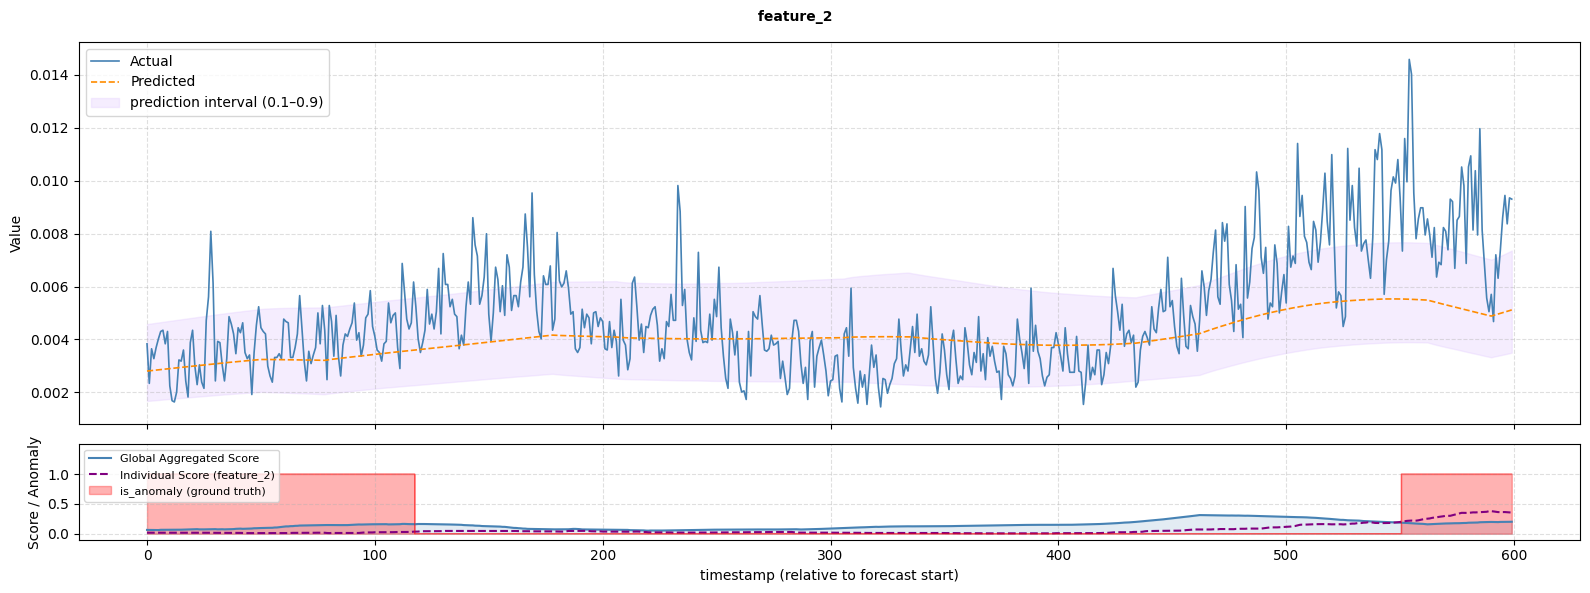

In [11]:
plot_forecast_with_anomaly(
        feature_groups, 
        df, 
        y_score, 
        anomaly_df,
        label, 
        feature_list,
        feature_idx=1, 
        plot_from=2944,   
        plot_until=3544,  
        smooth_window=100,
    )

### All Features, Same Zoom Window

Loops over every feature with the same view bounds — useful for spotting which features actually carry the anomaly signal.

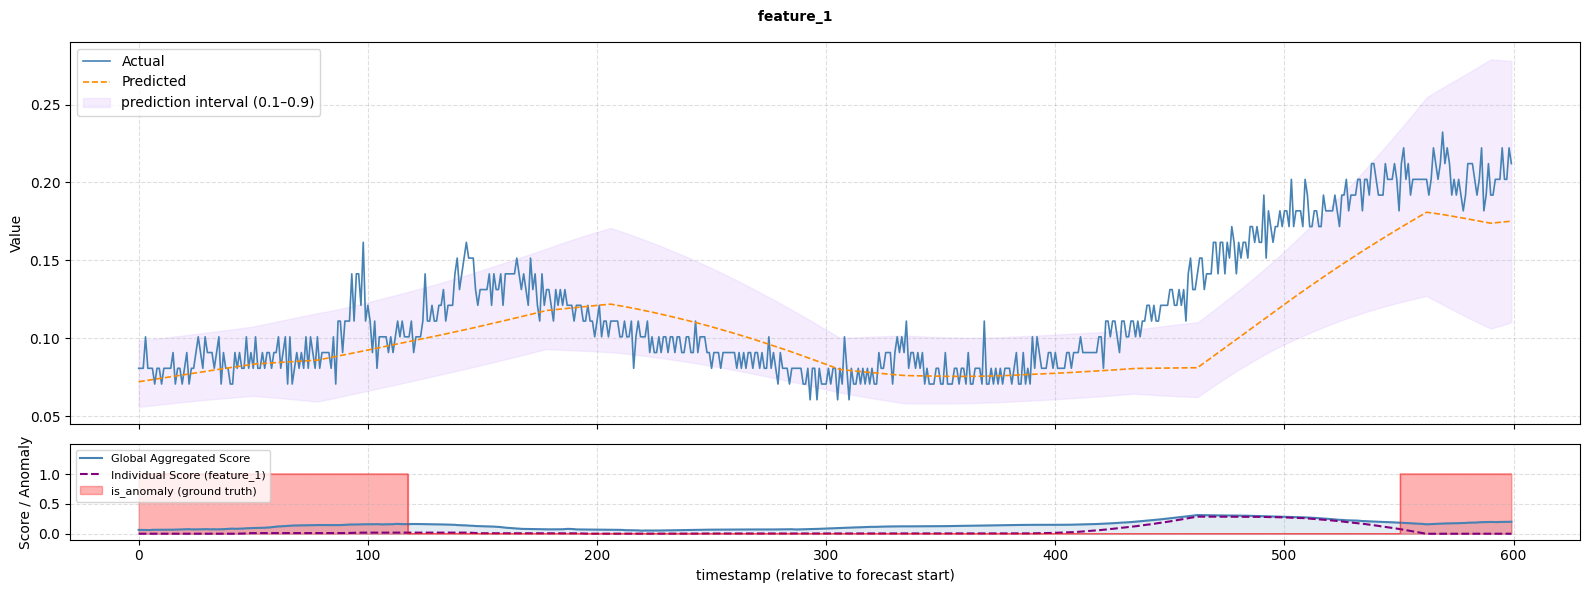

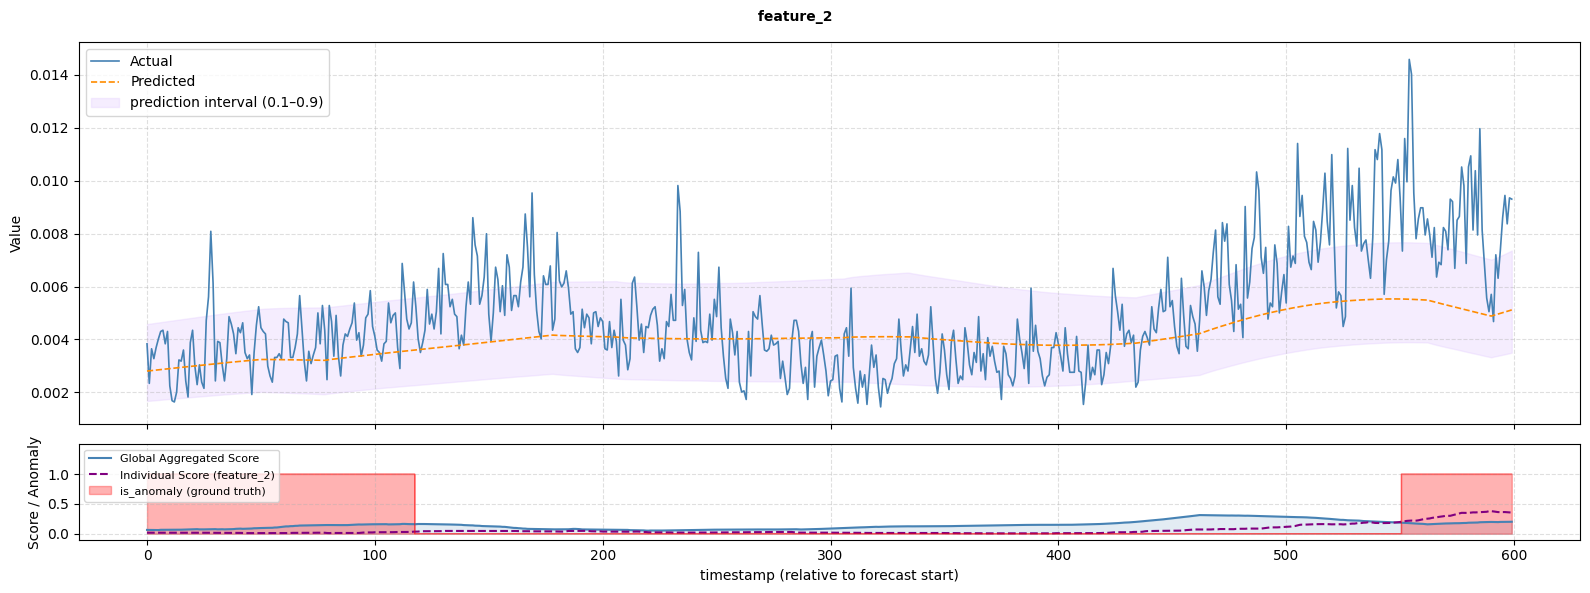

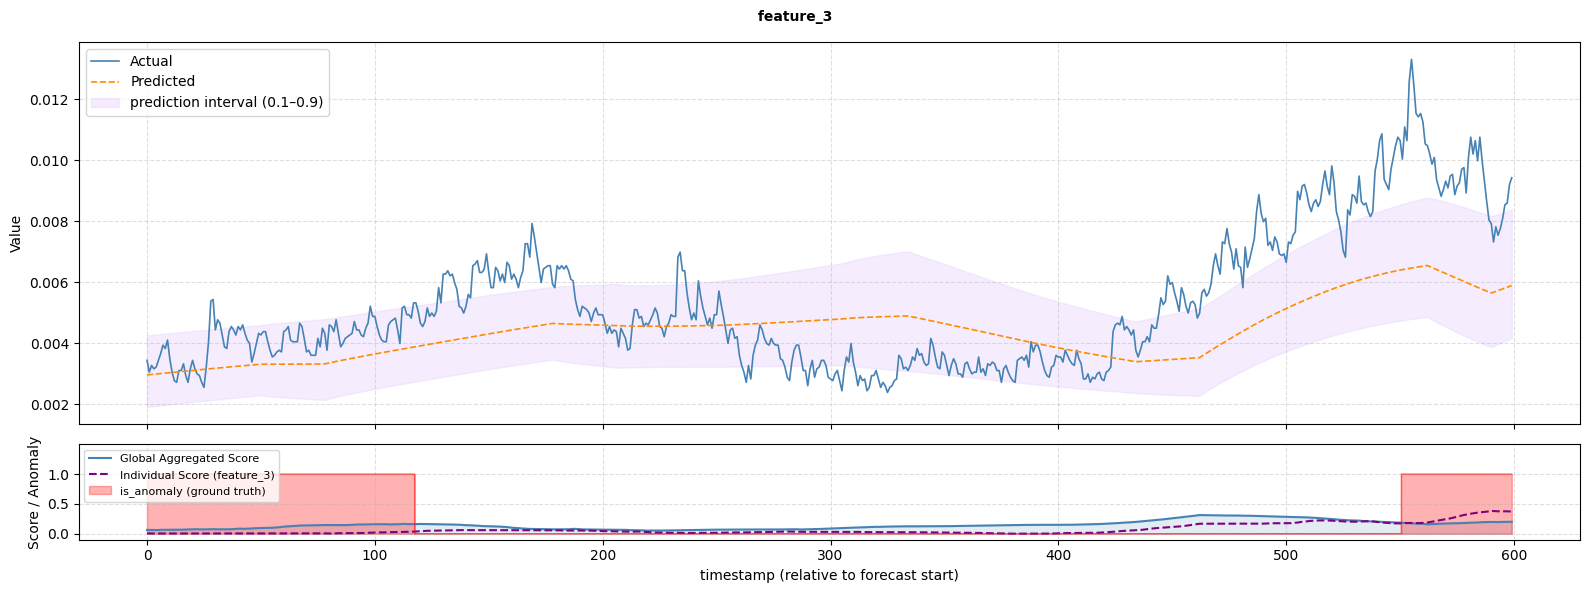

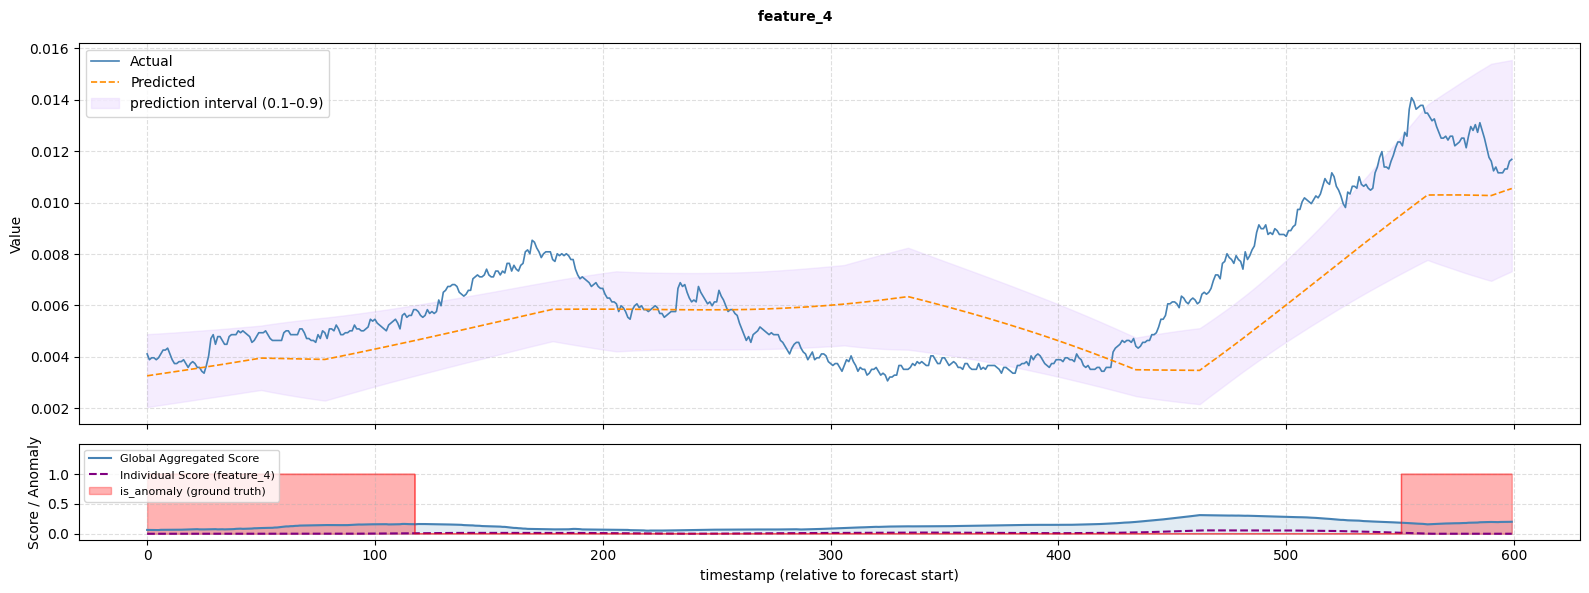

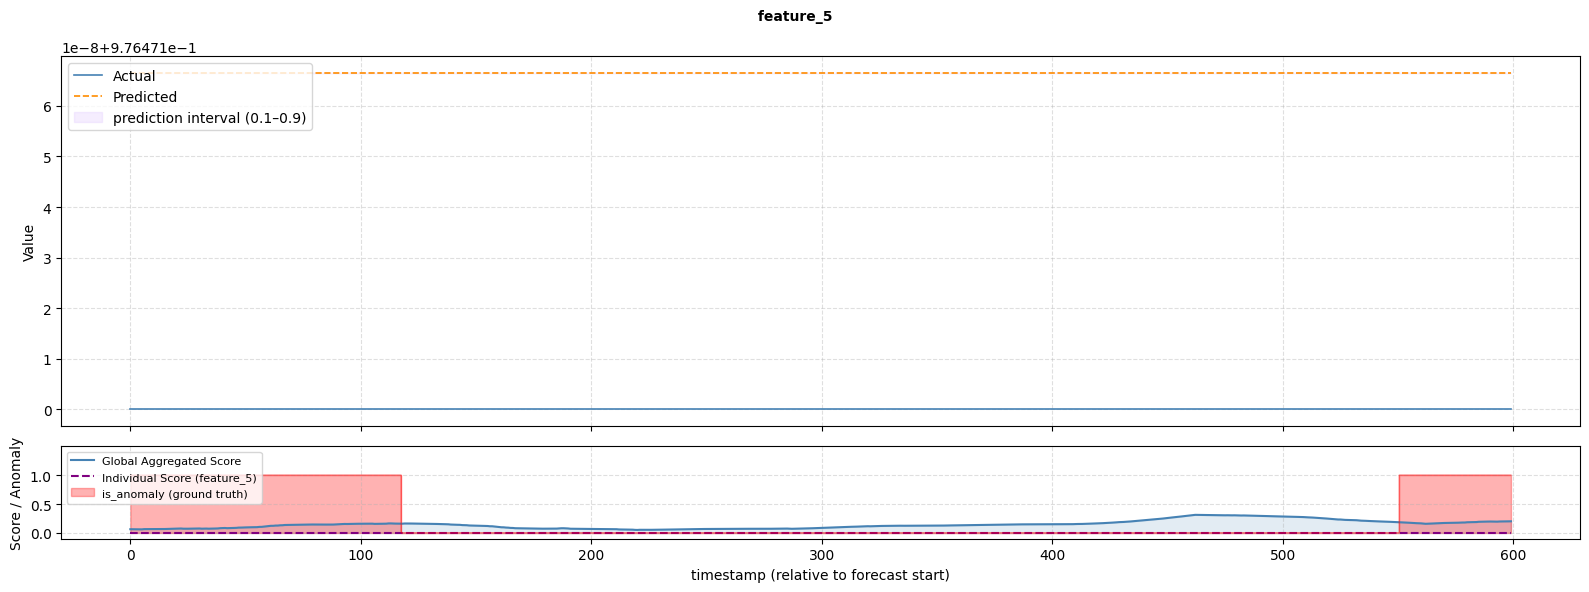

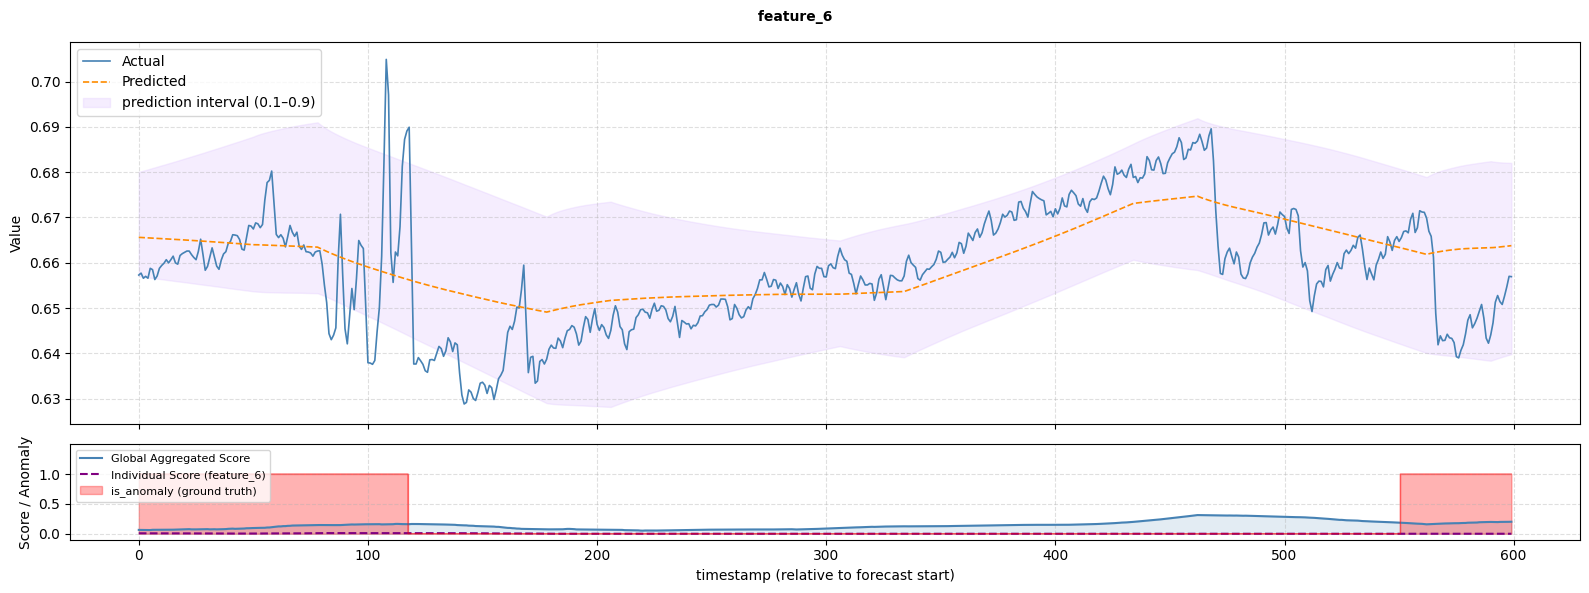

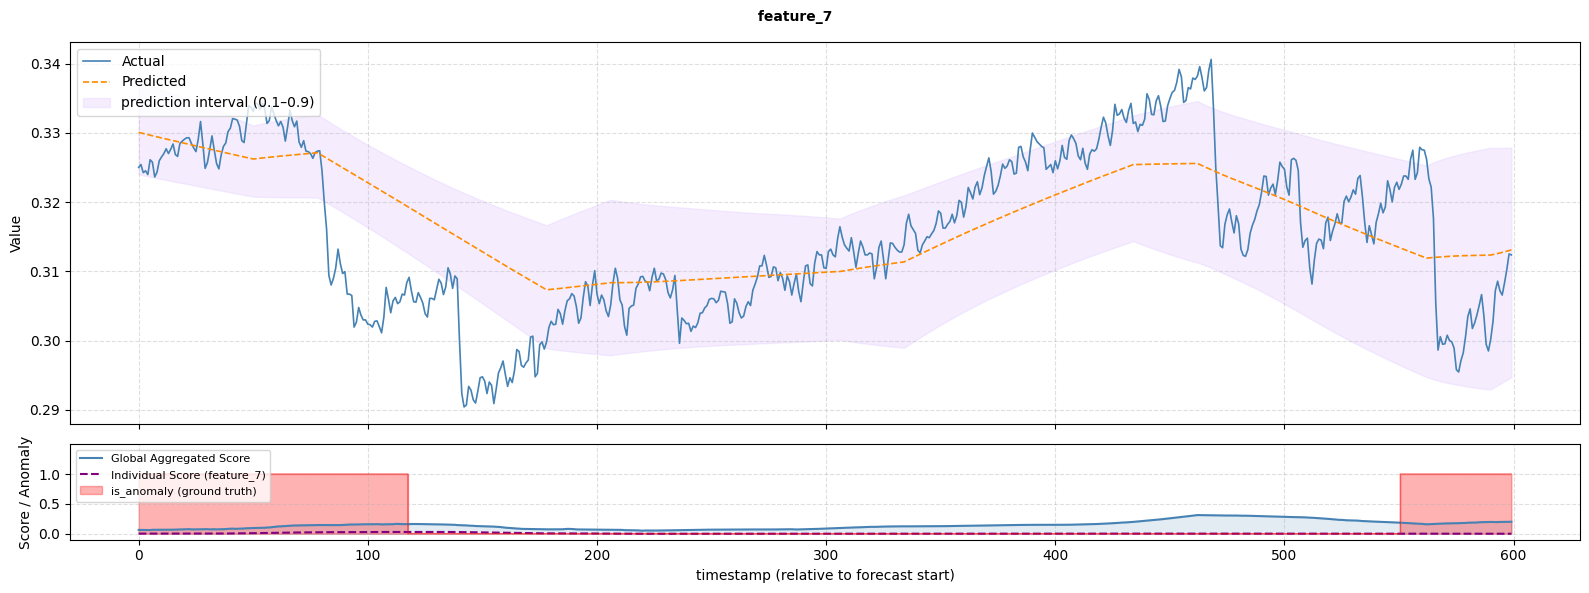

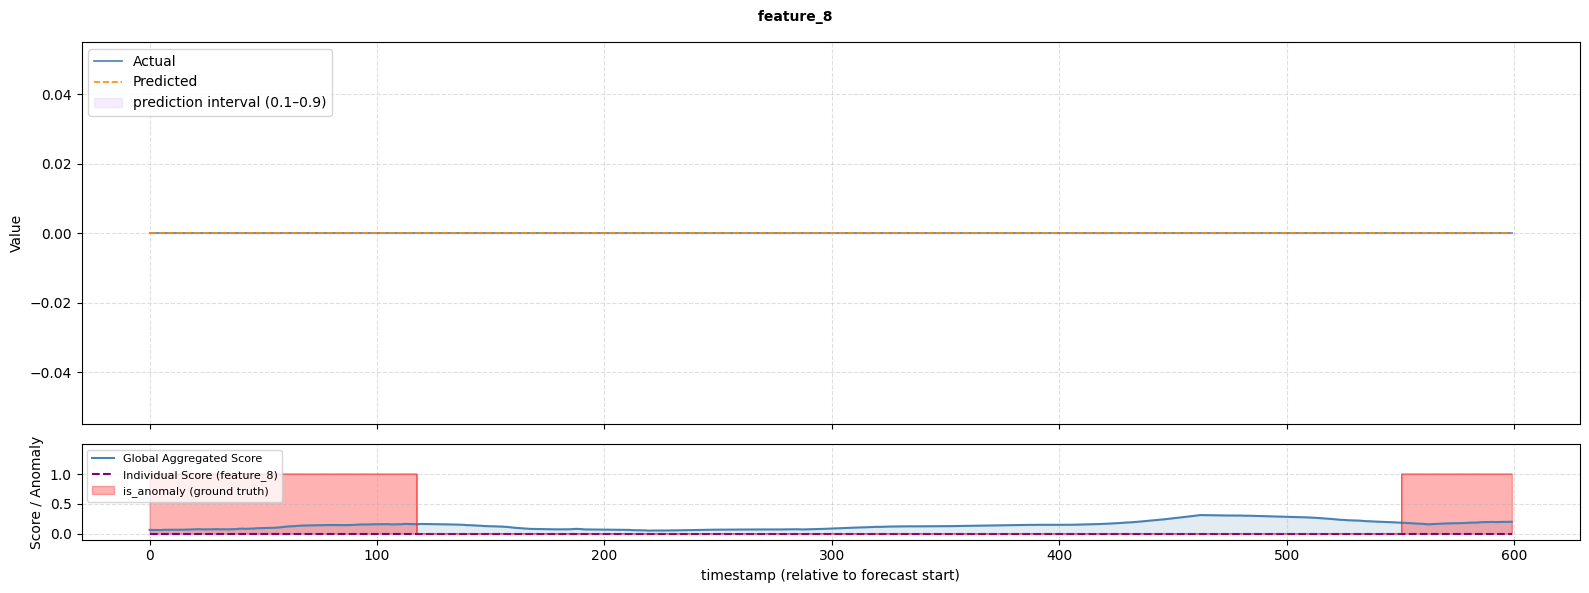

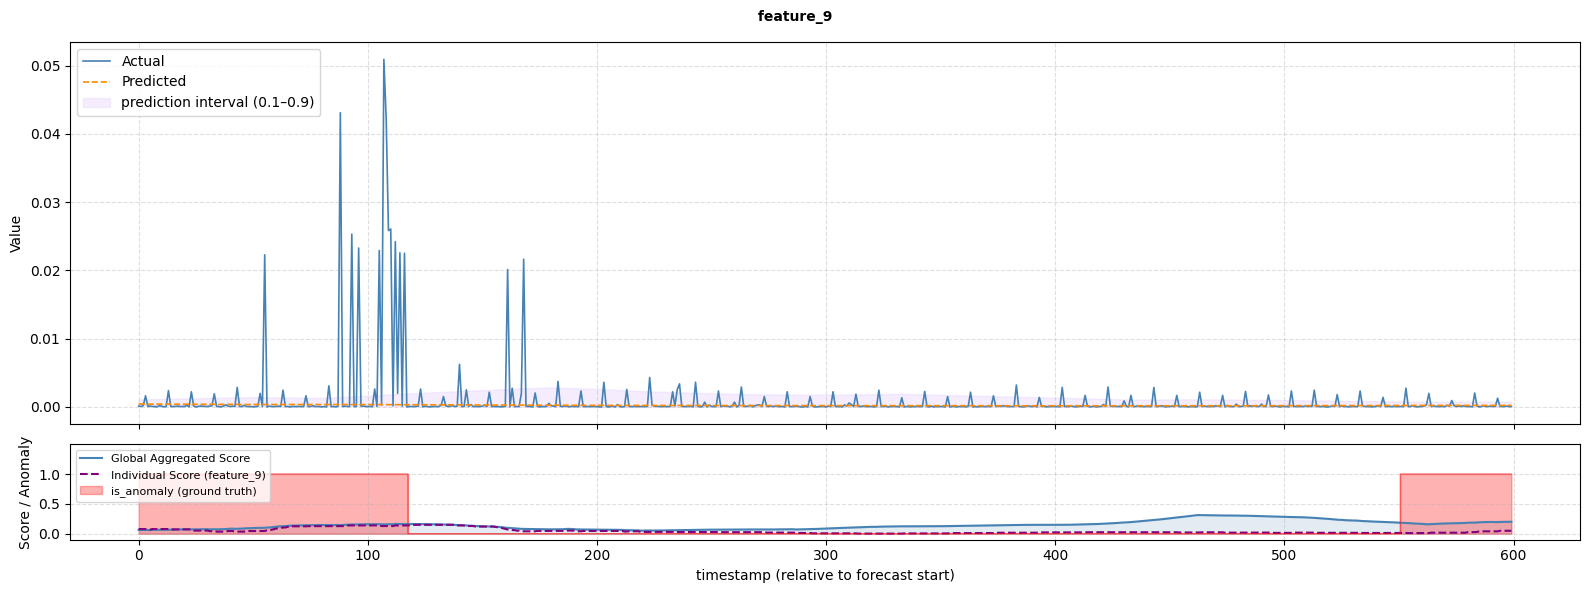

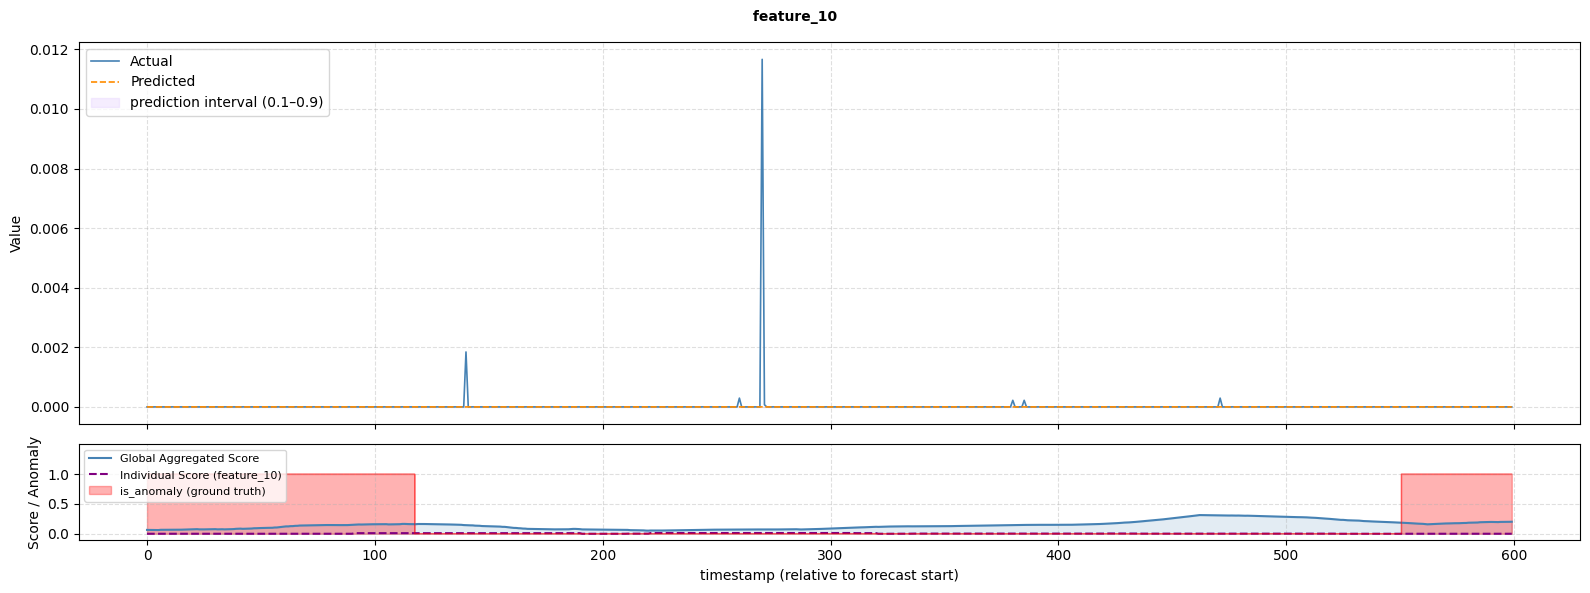

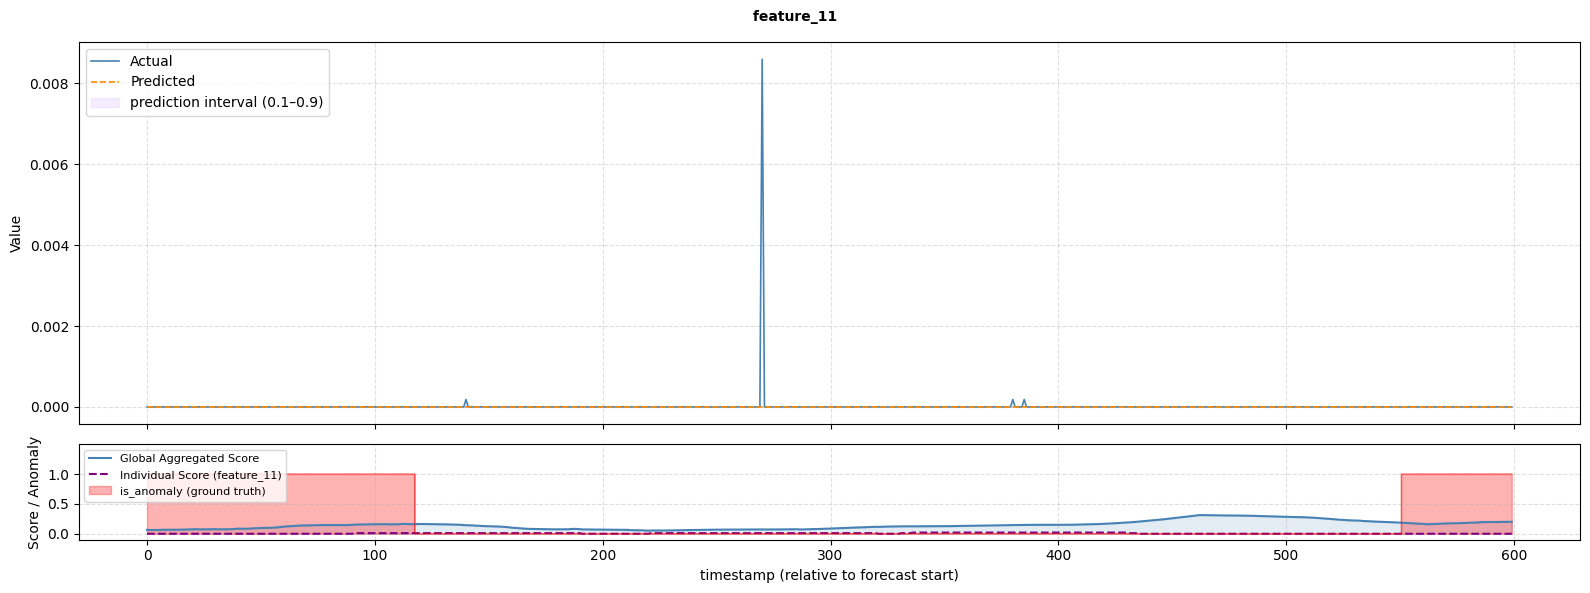

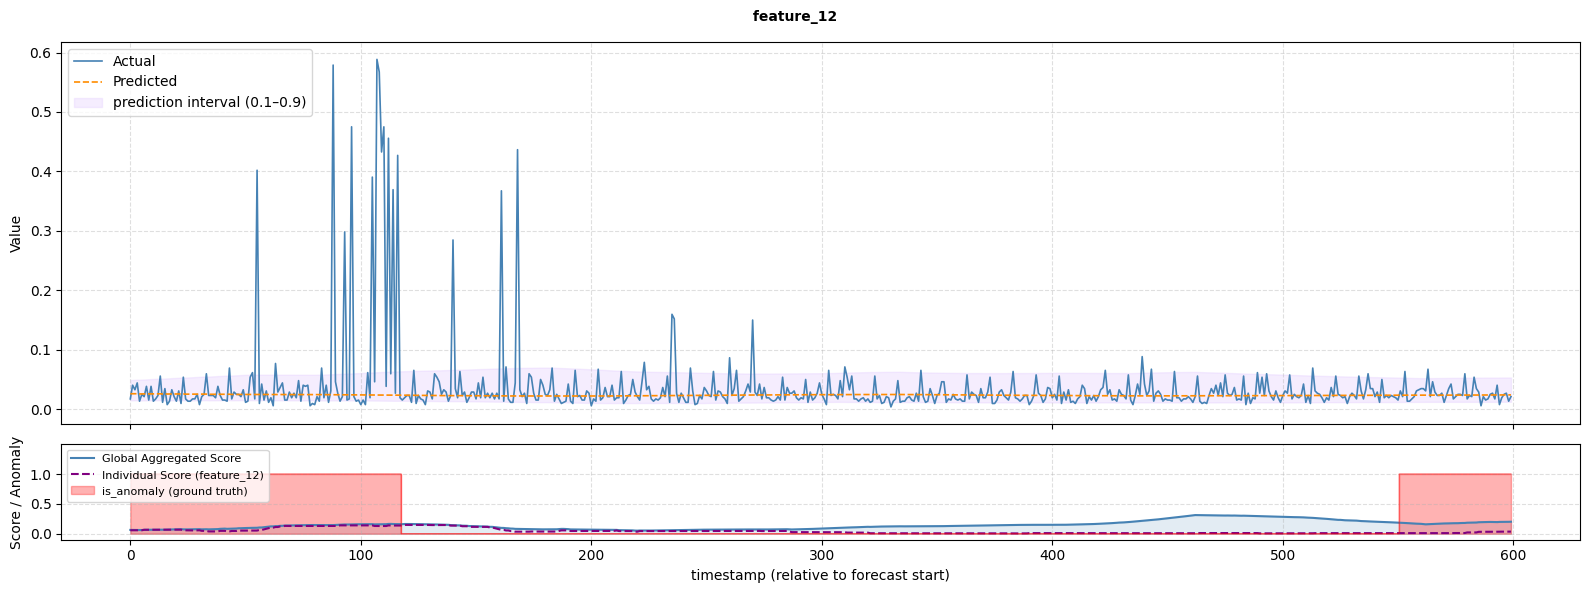

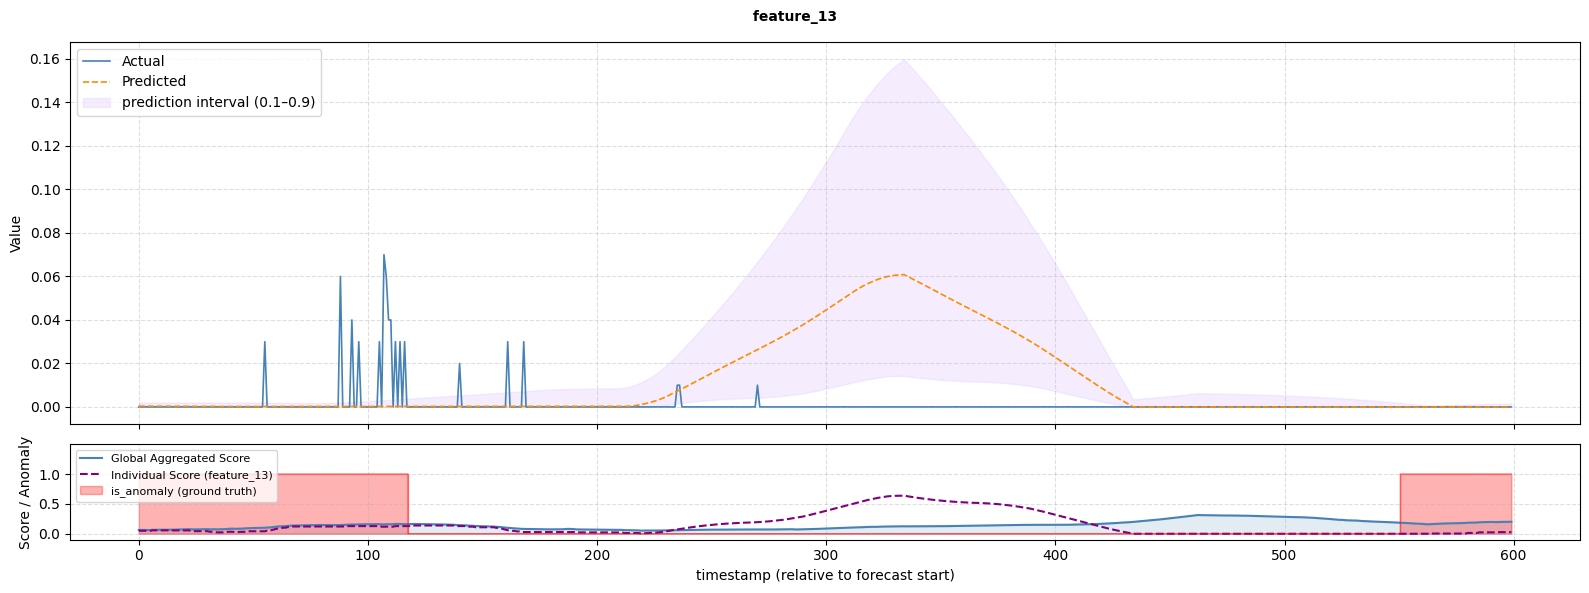

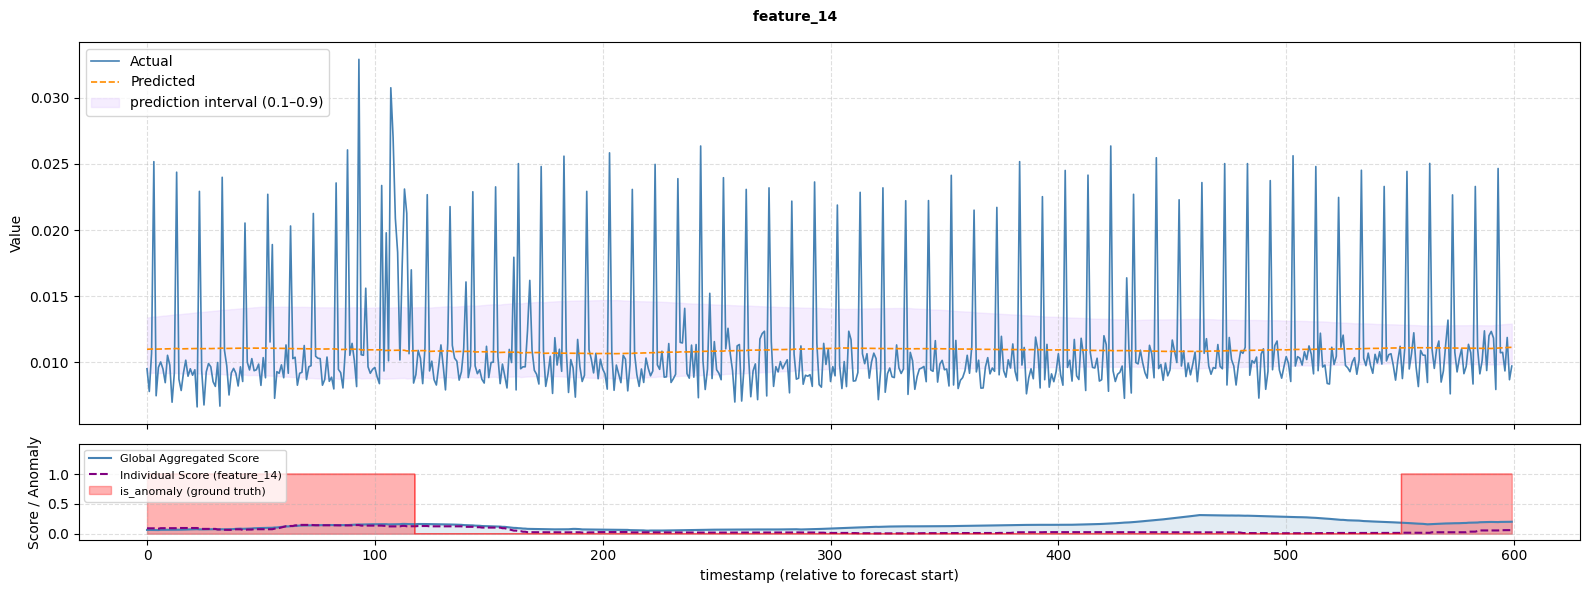

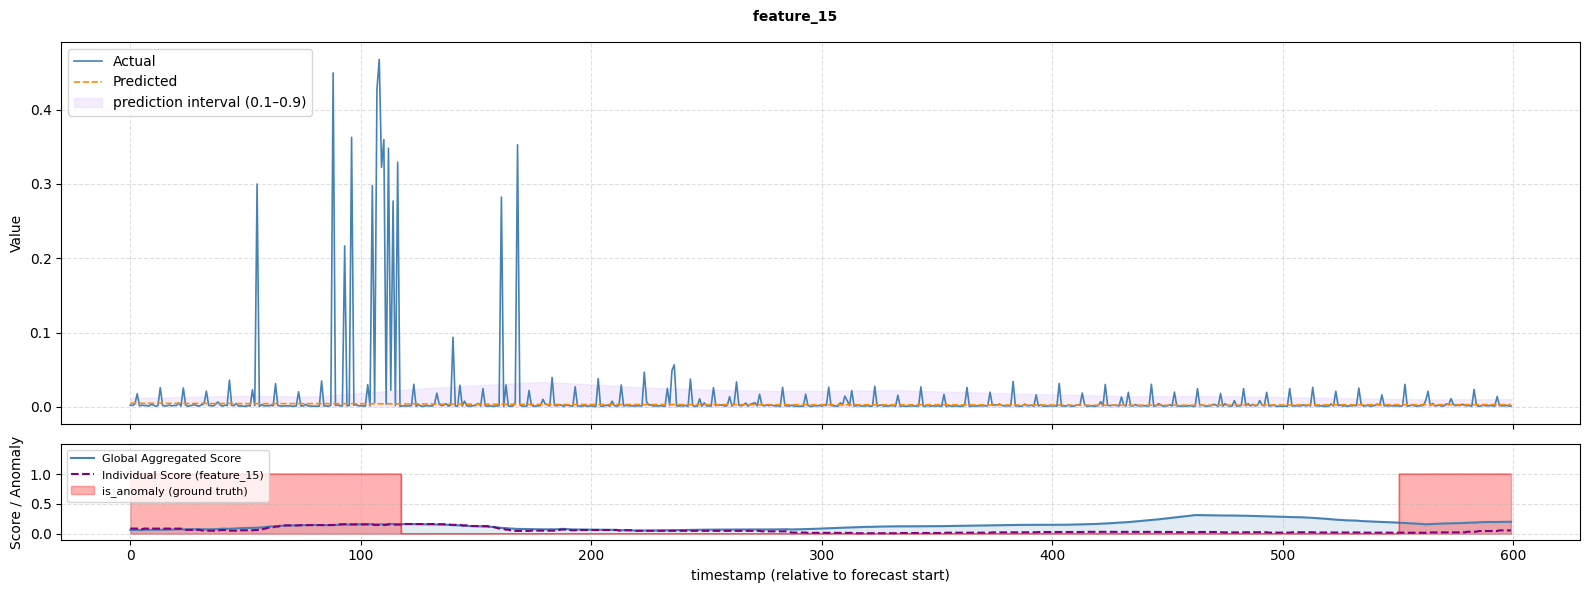

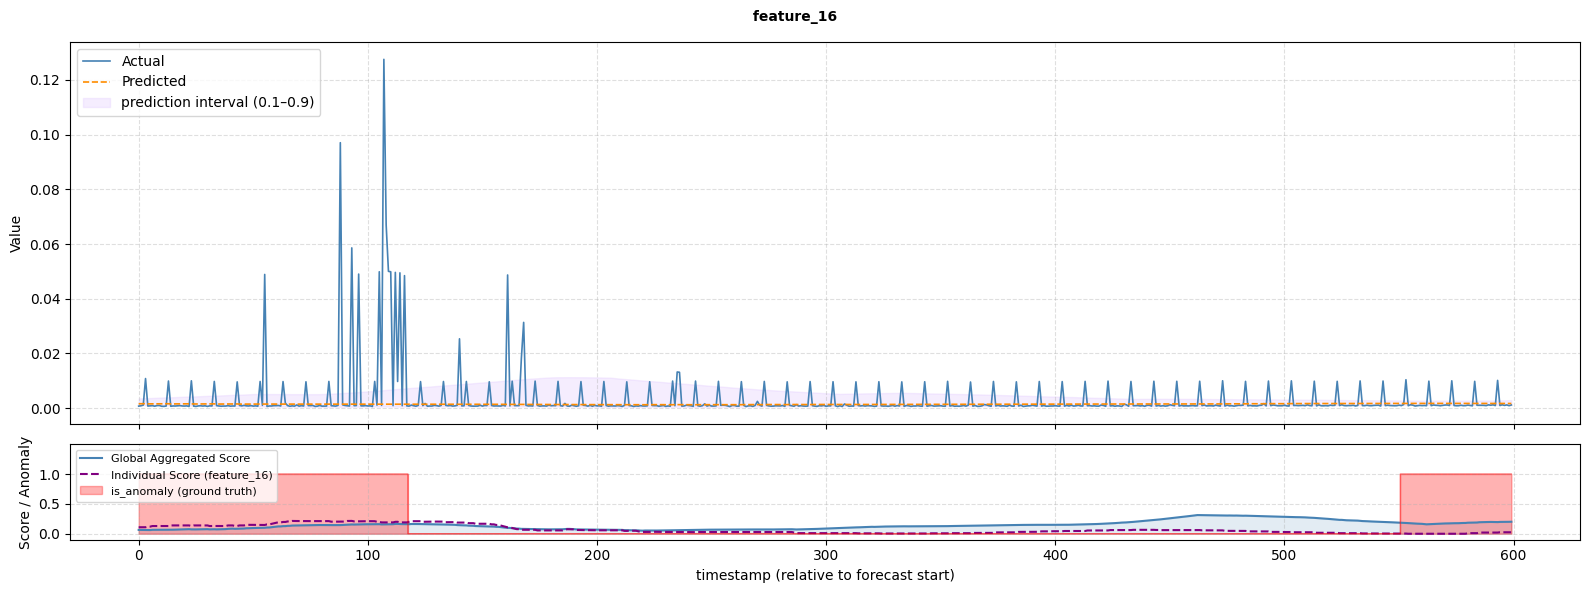

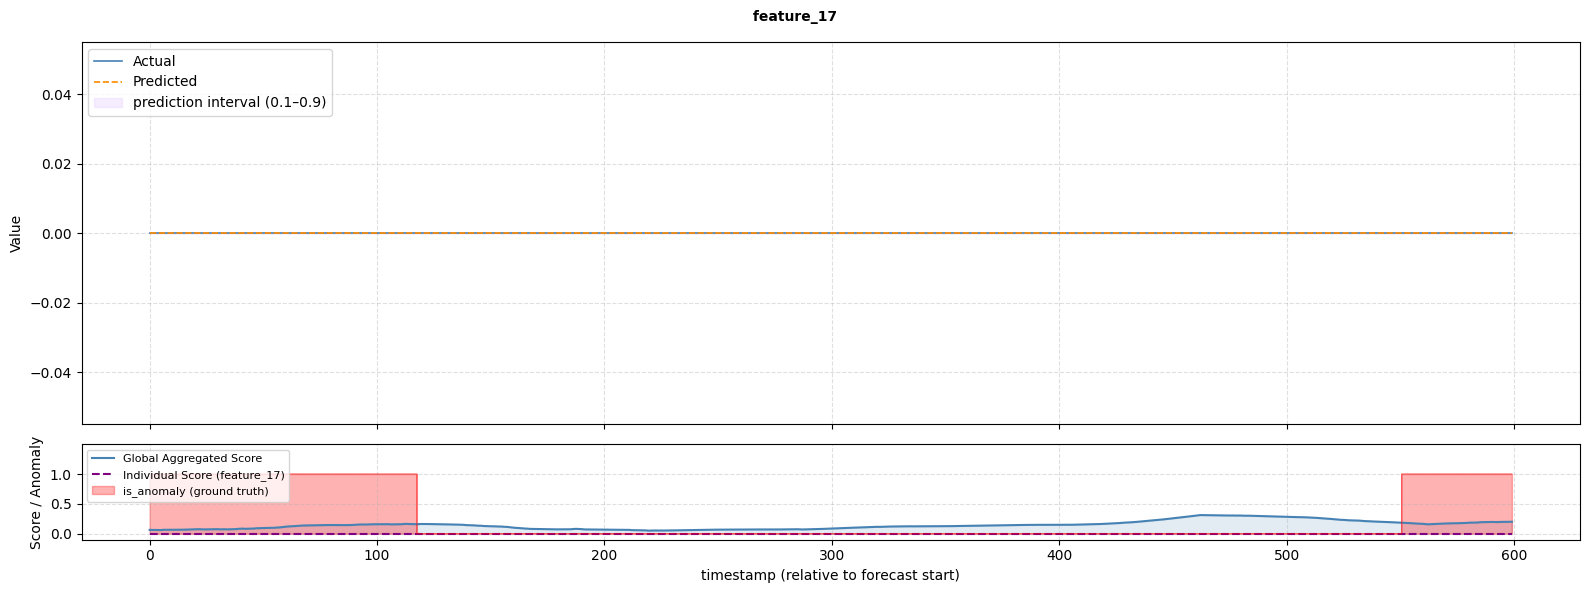

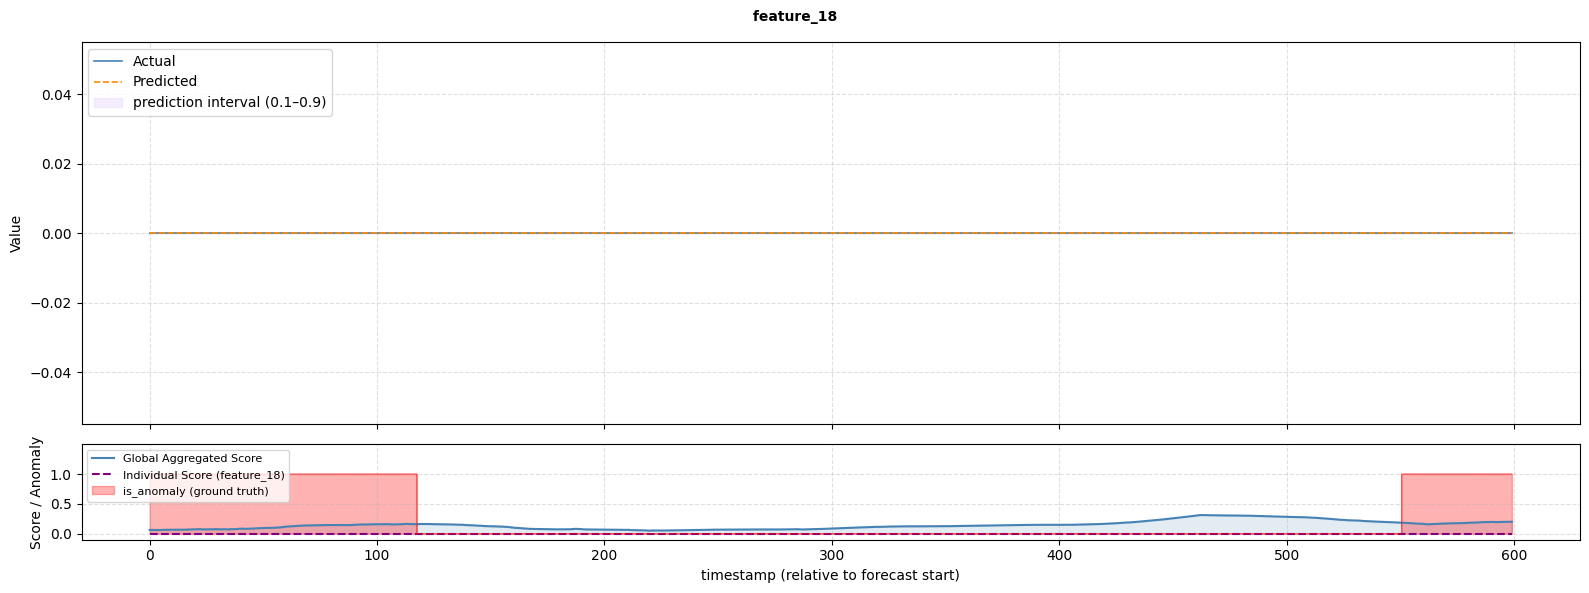

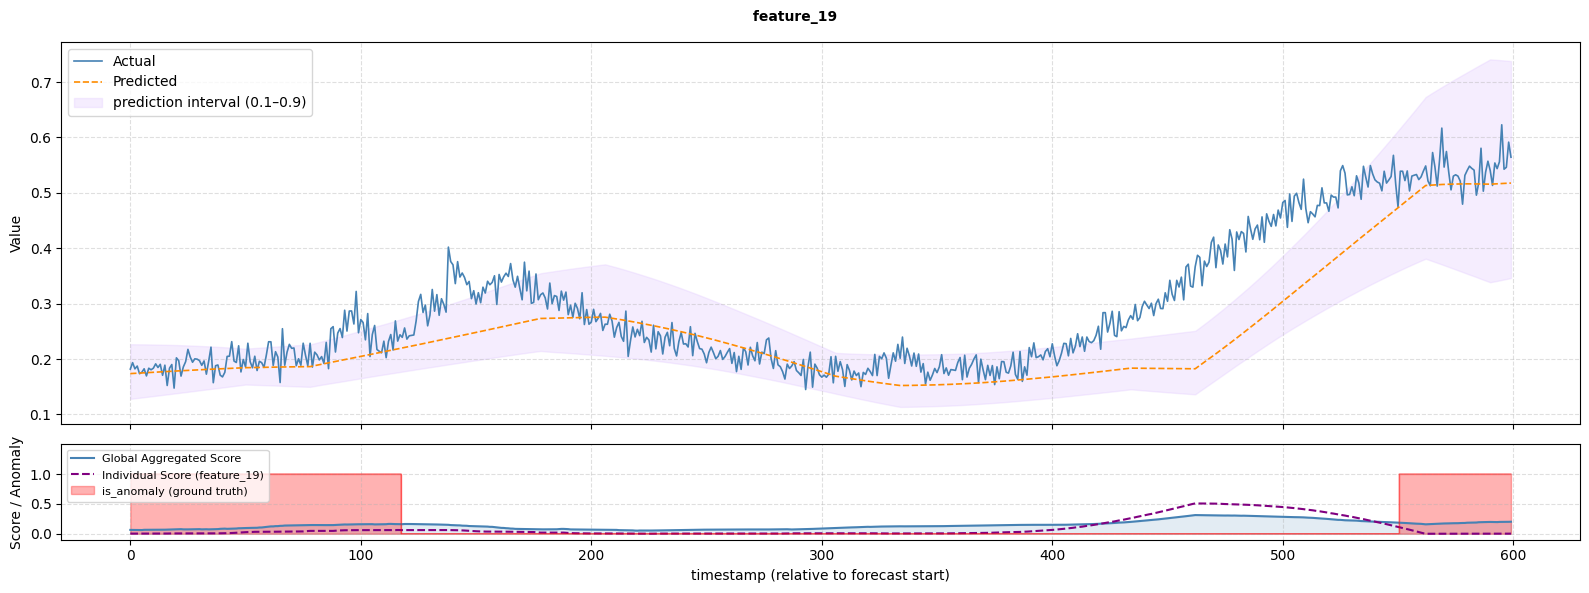

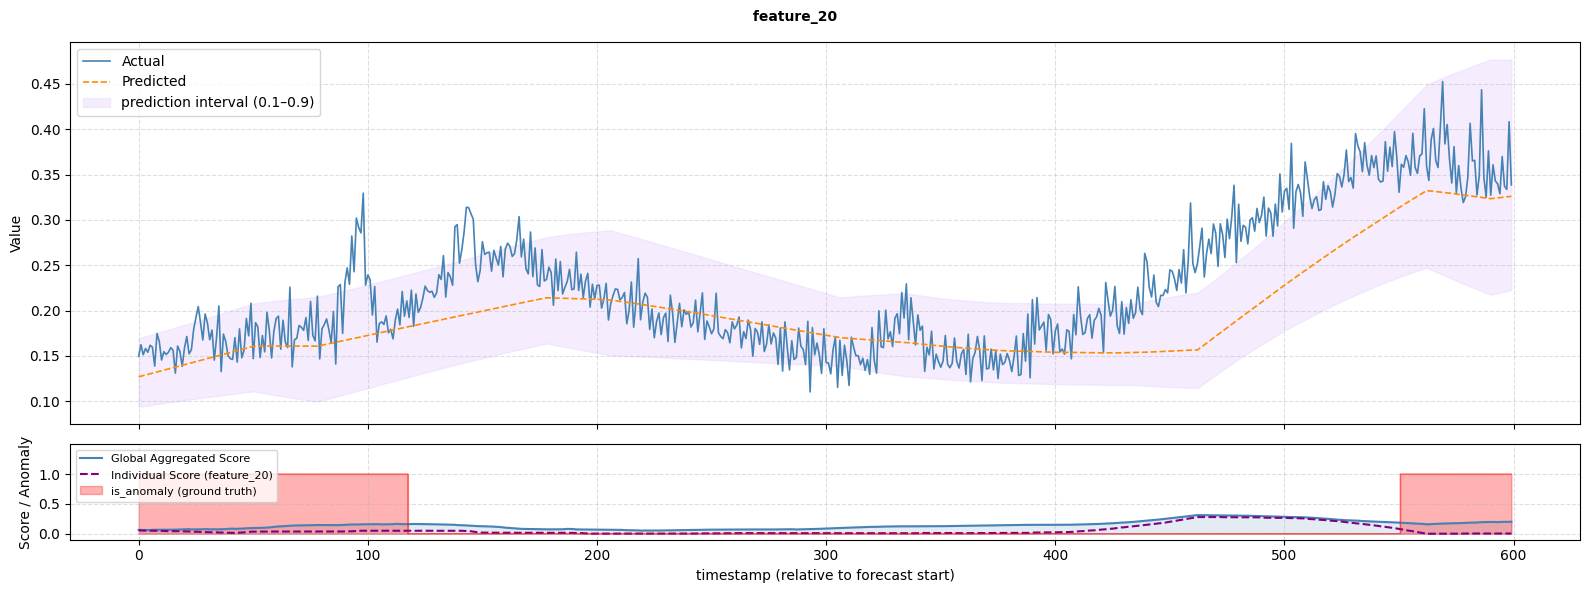

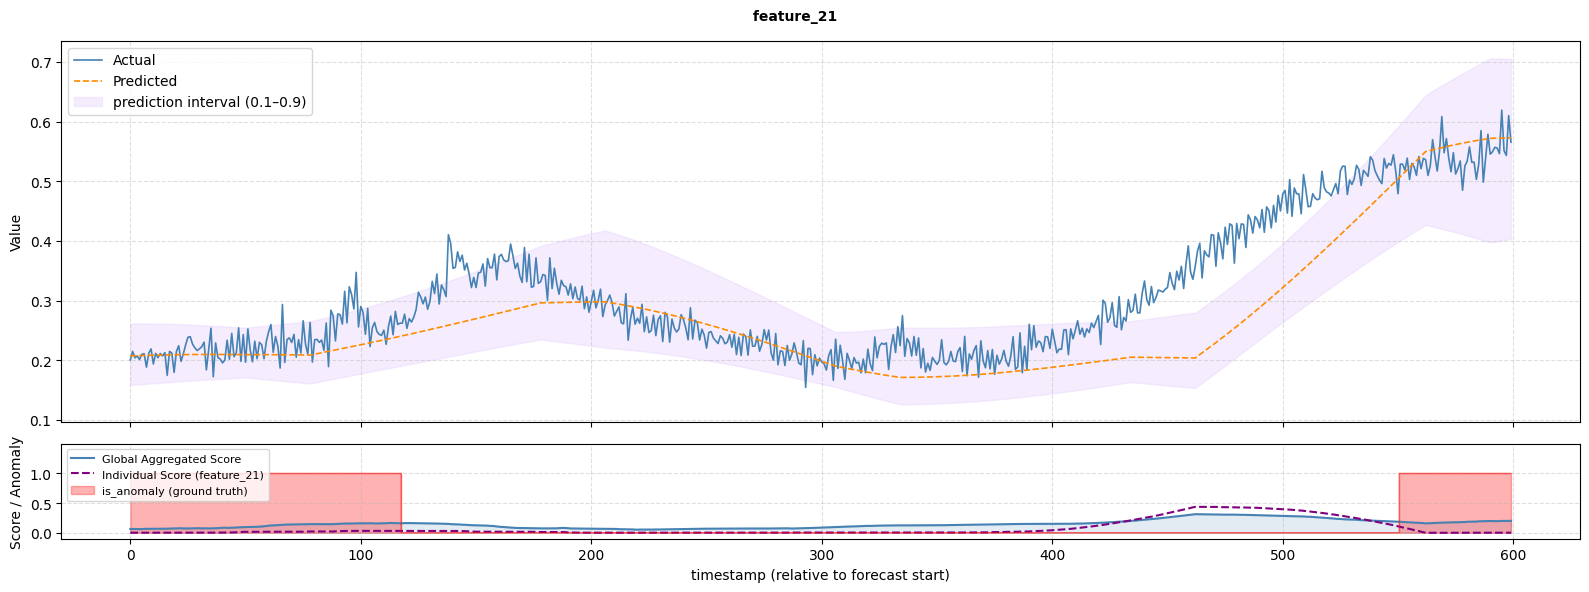

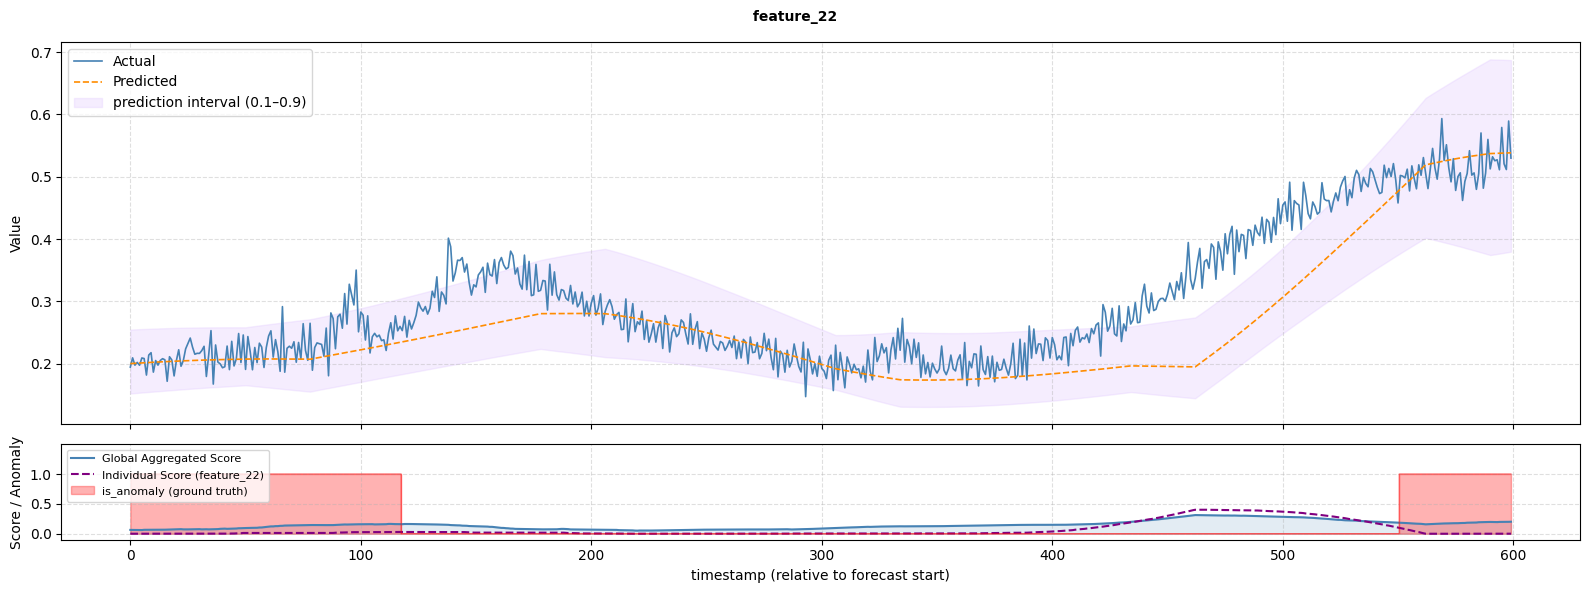

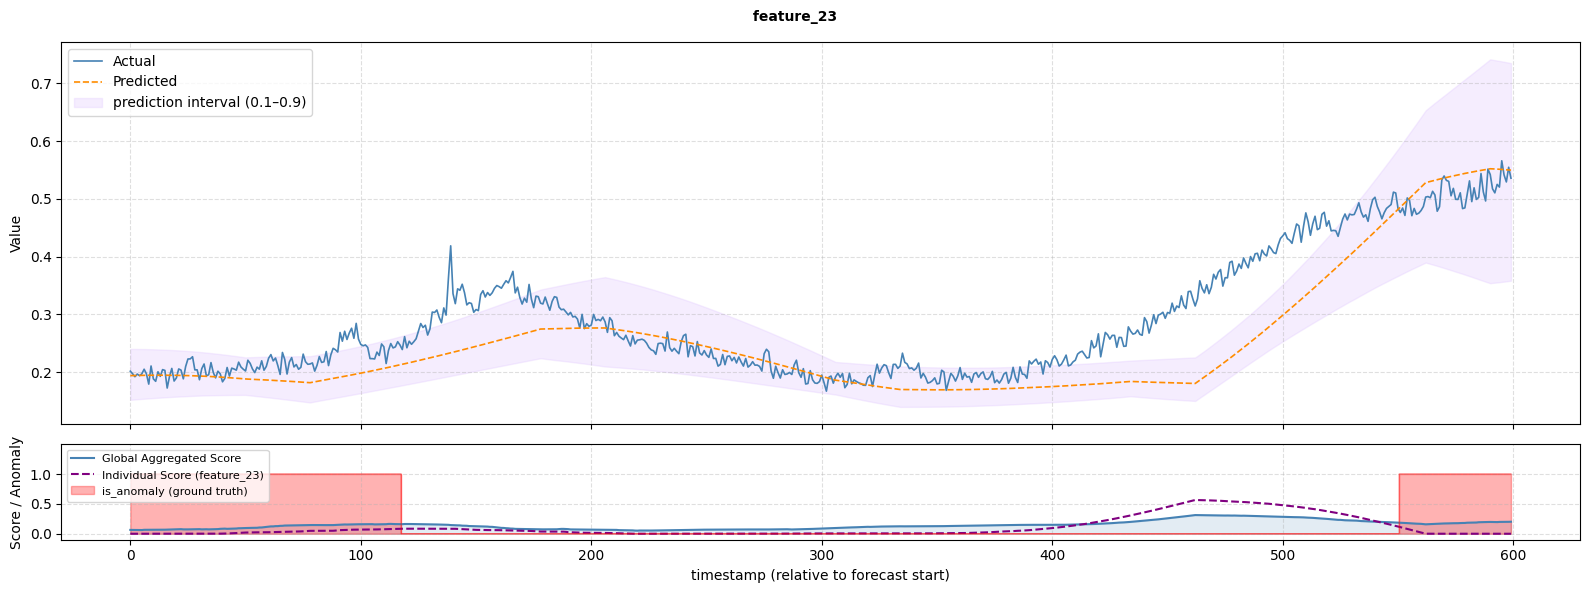

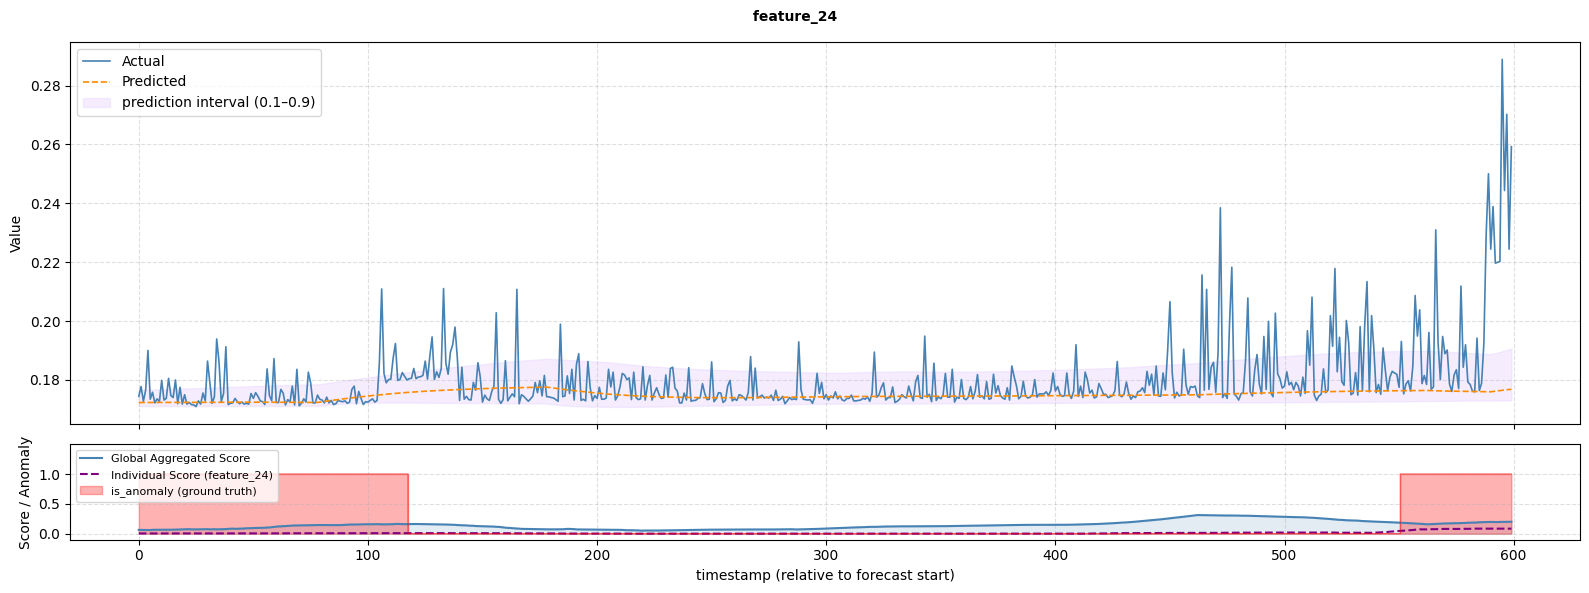

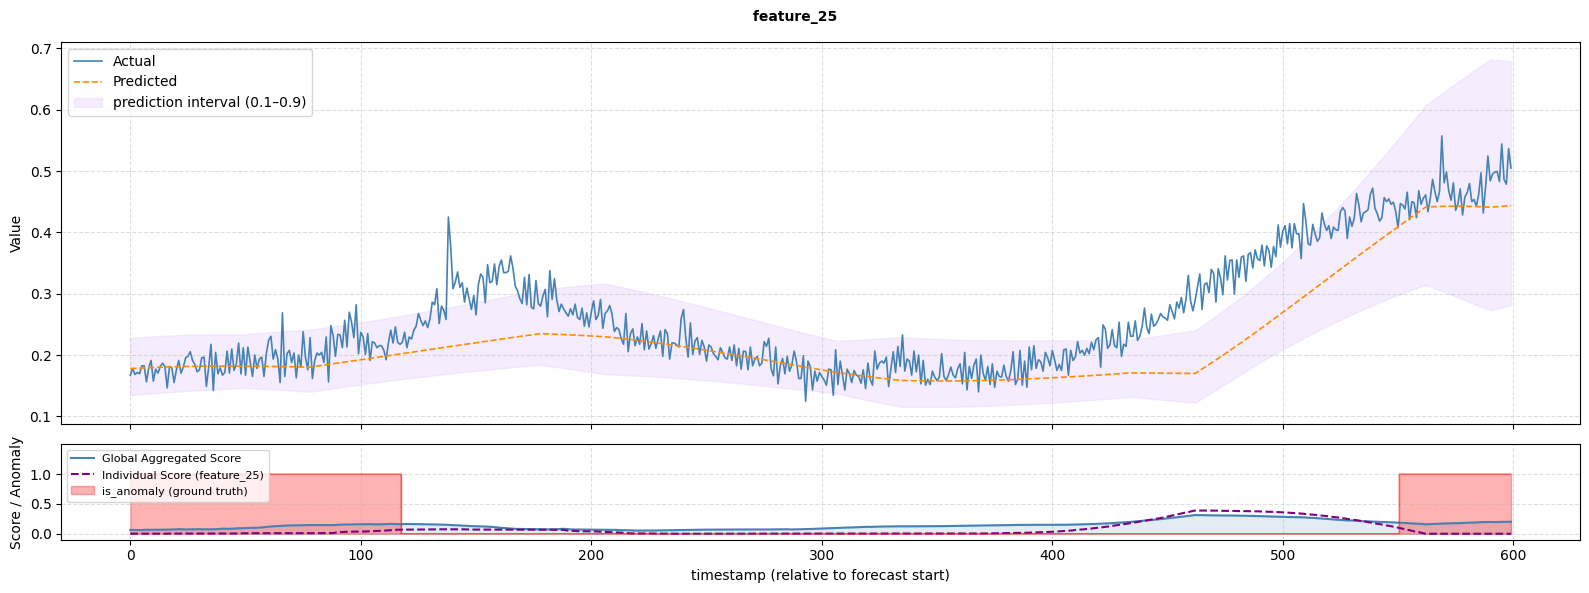

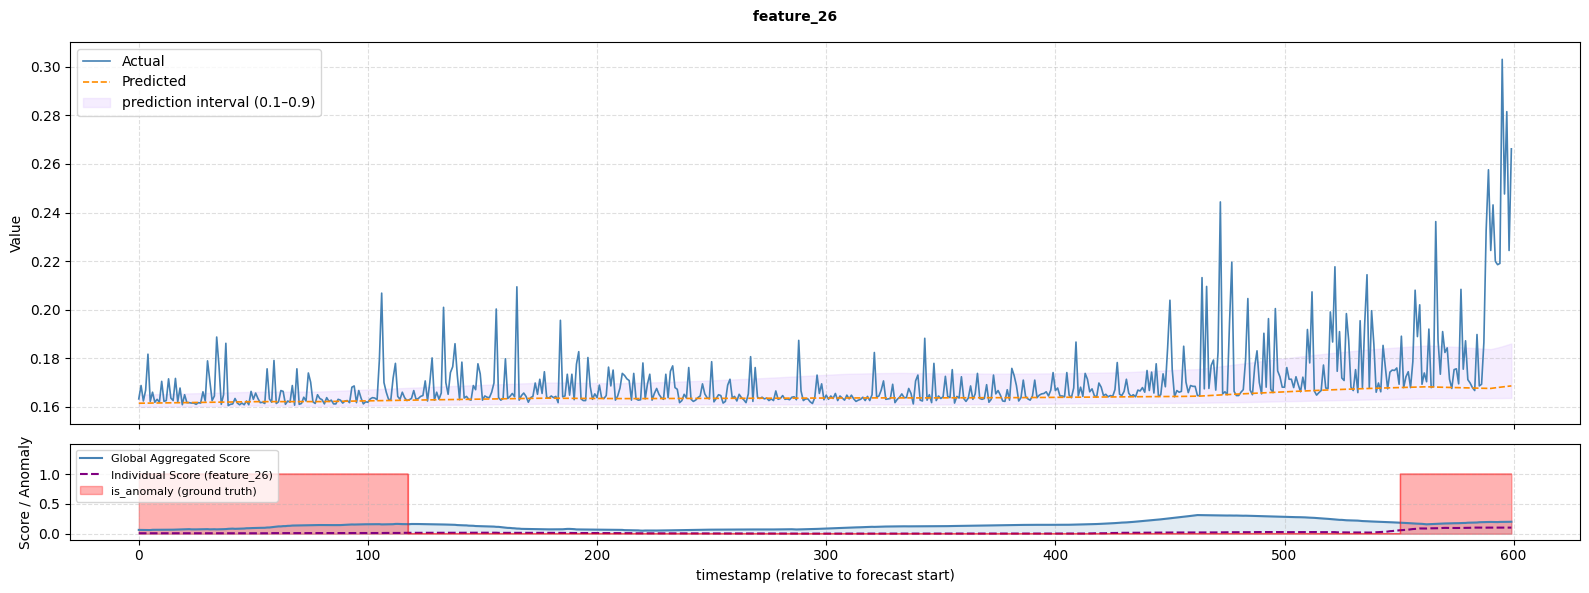

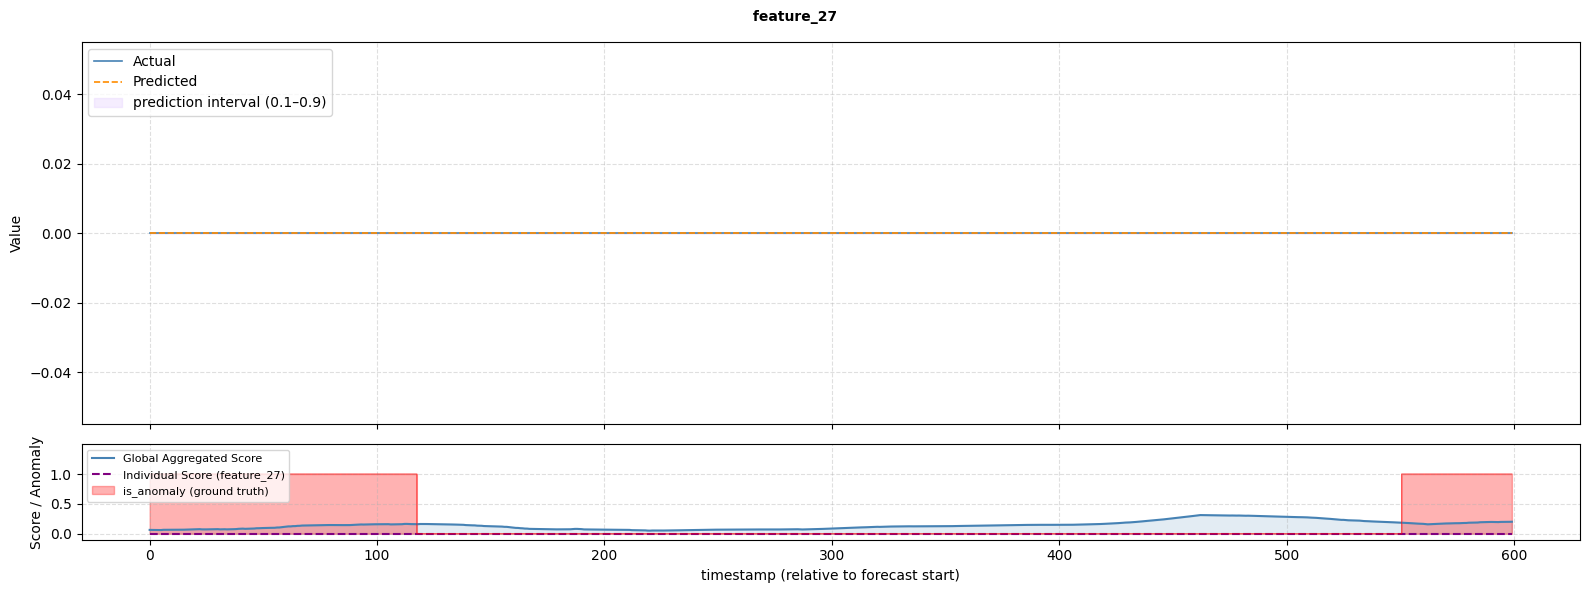

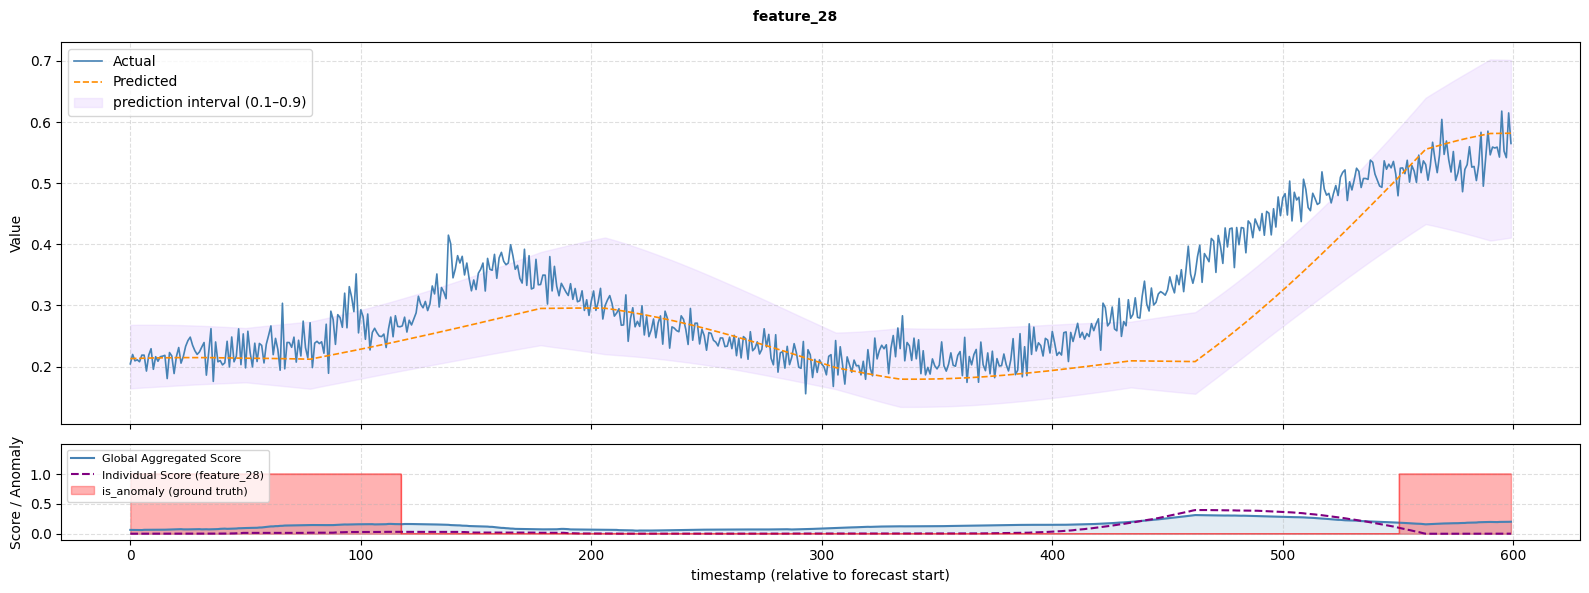

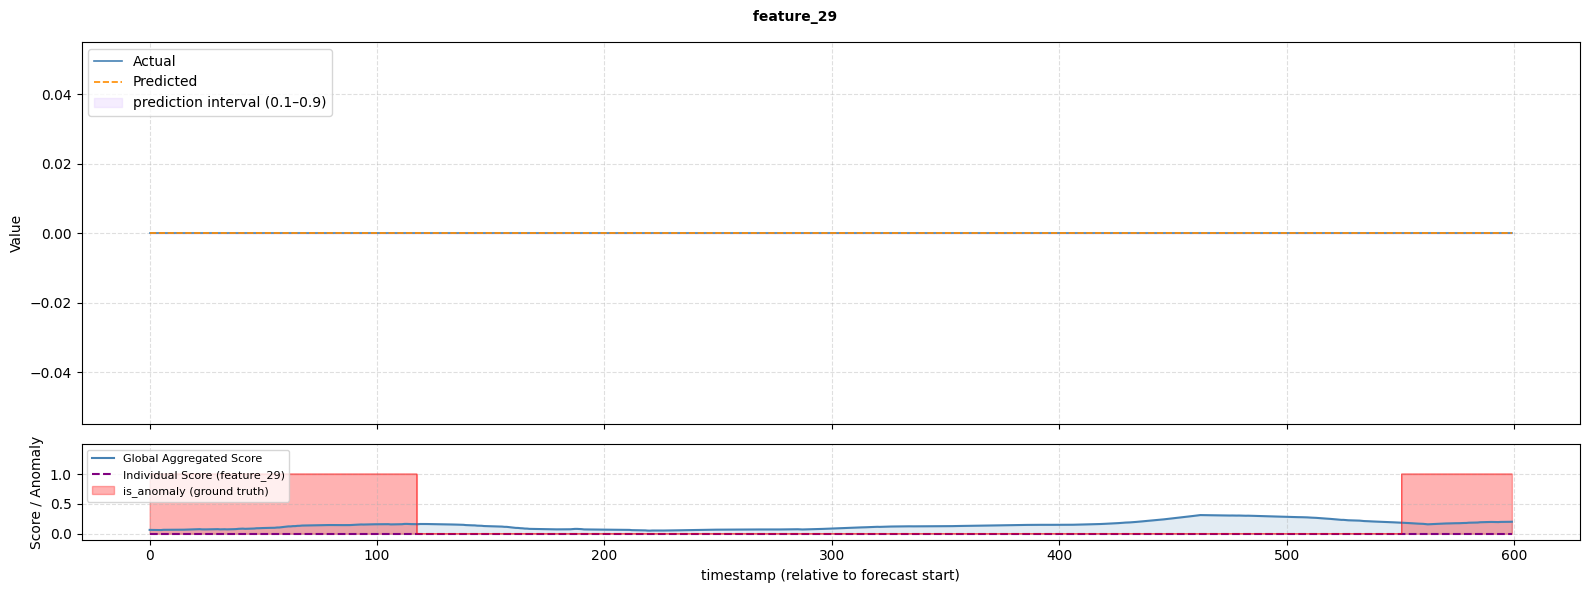

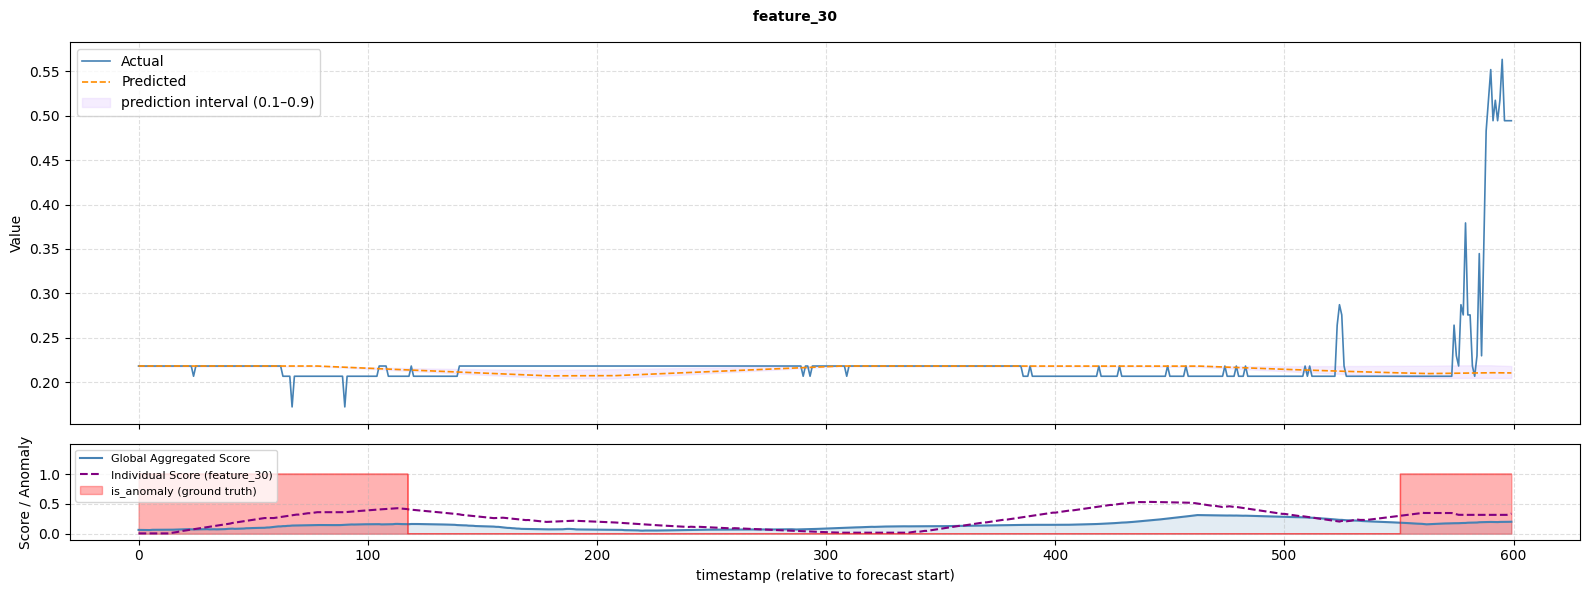

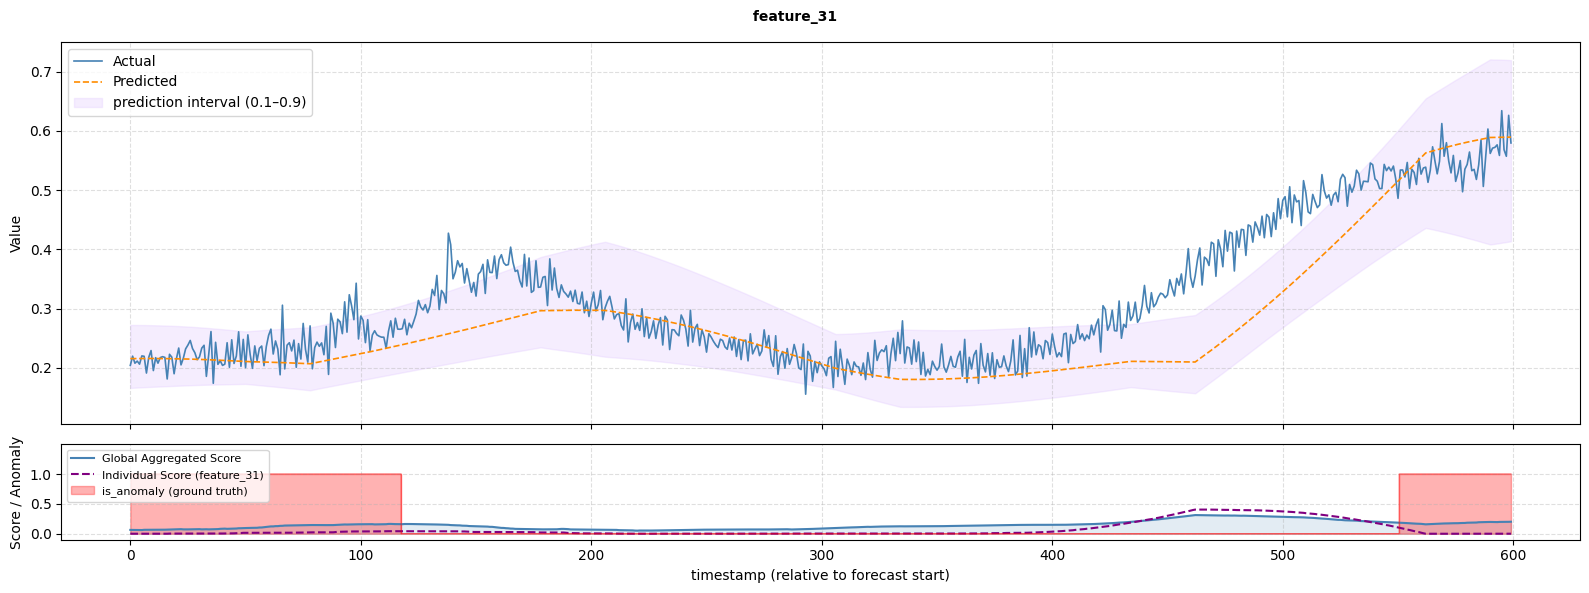

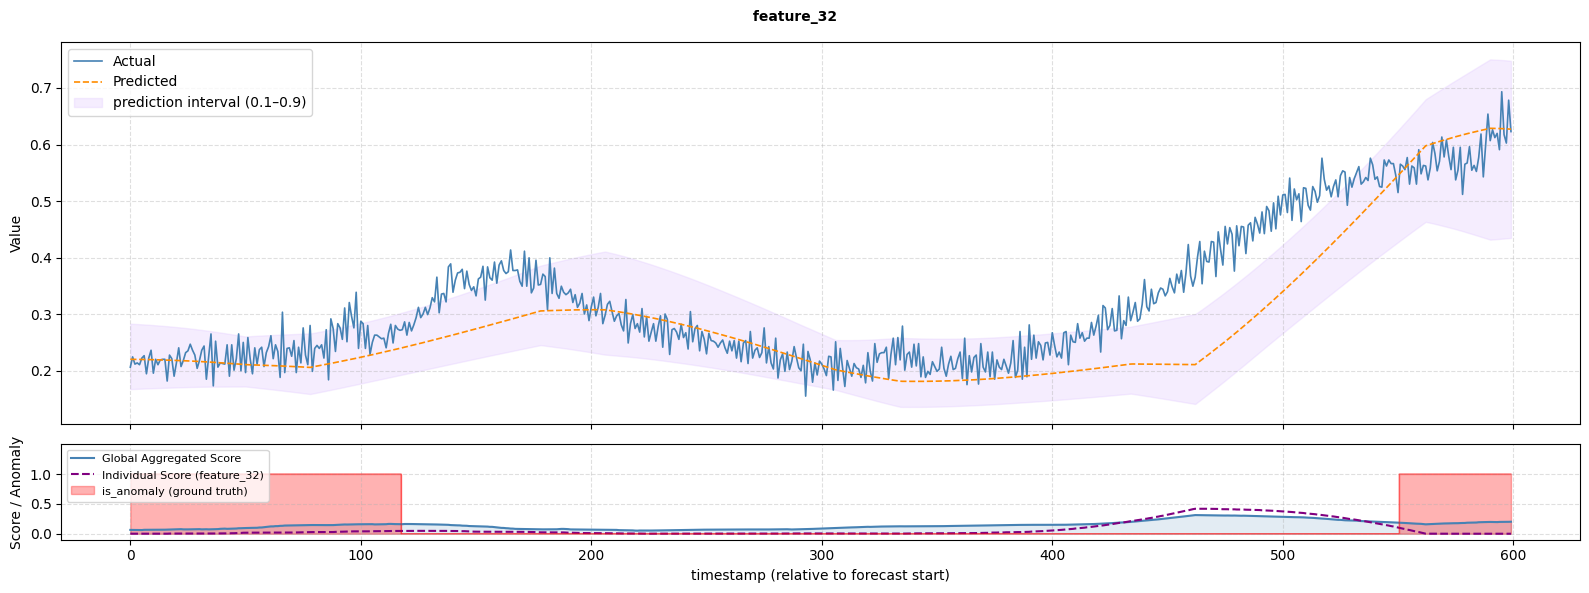

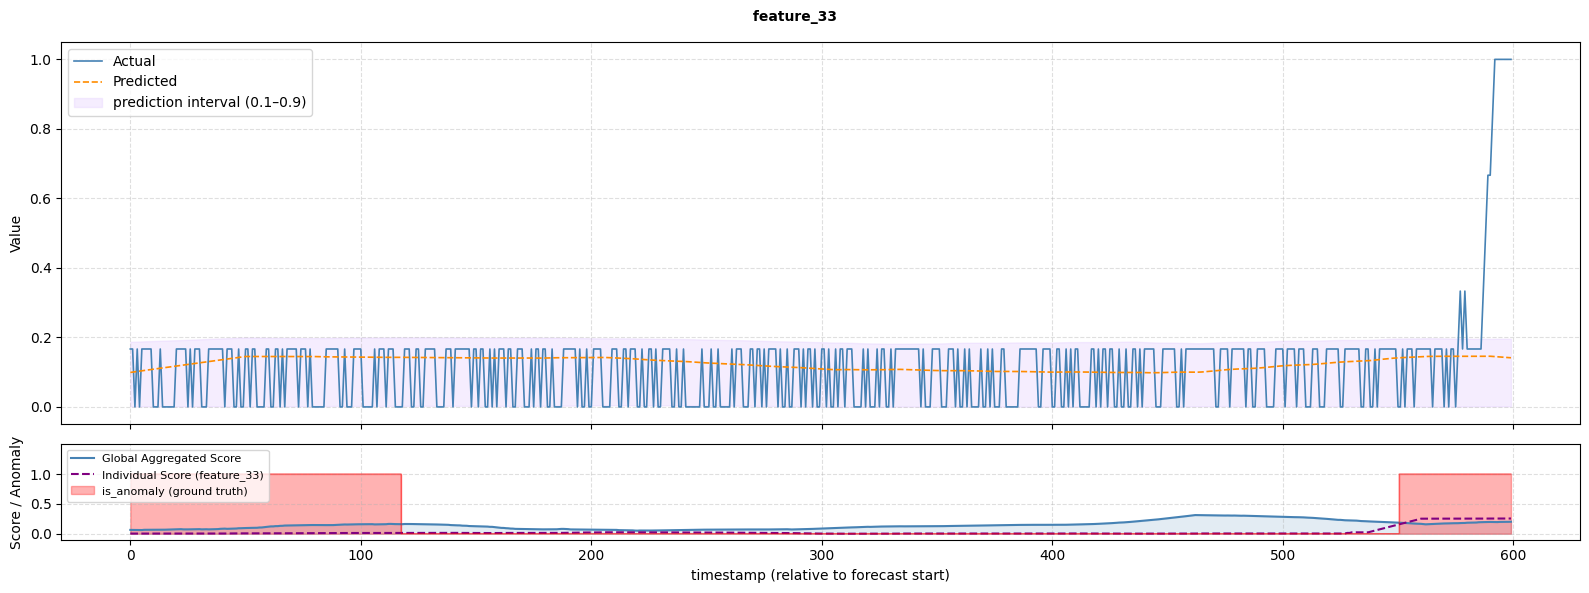

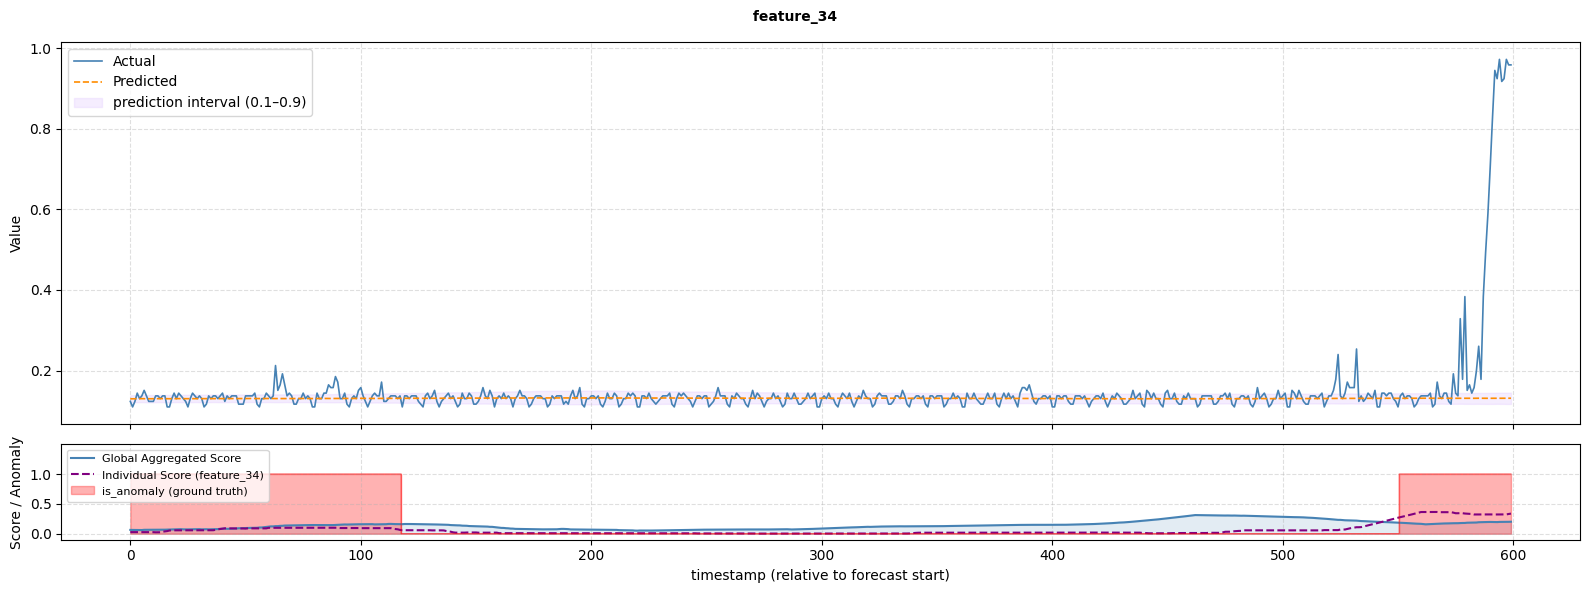

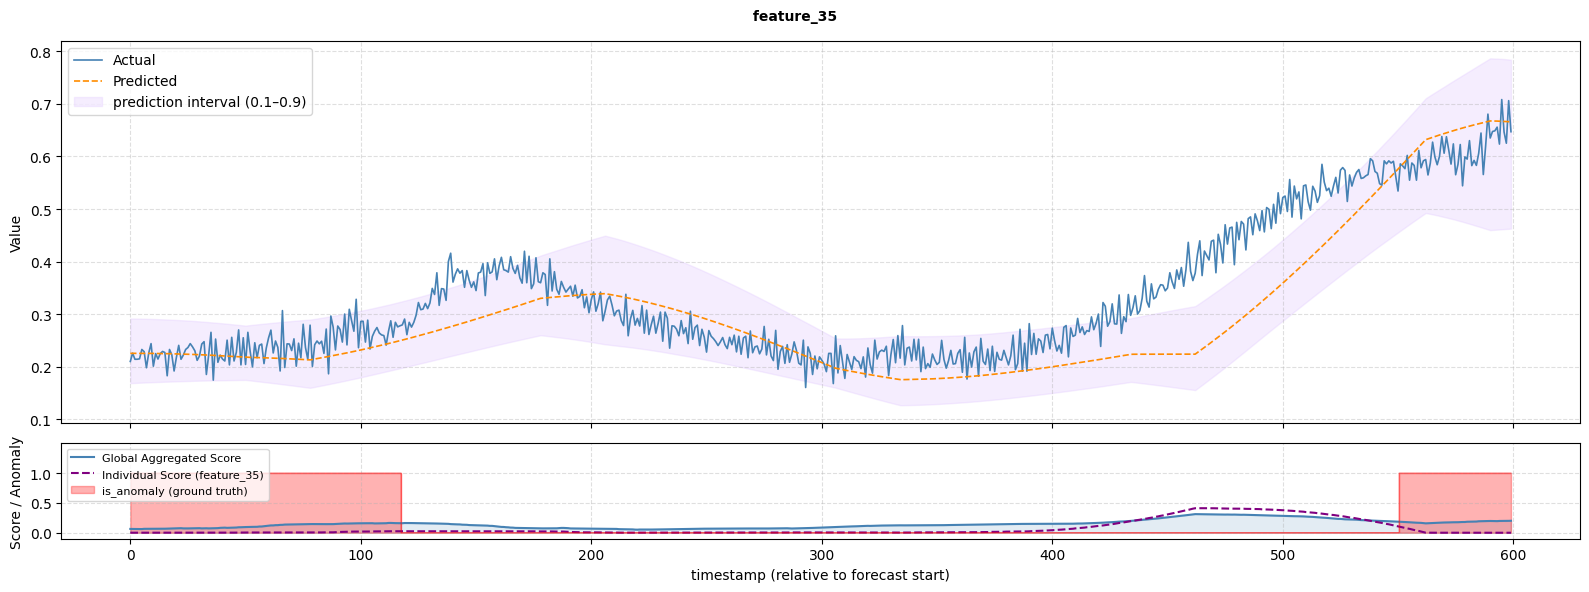

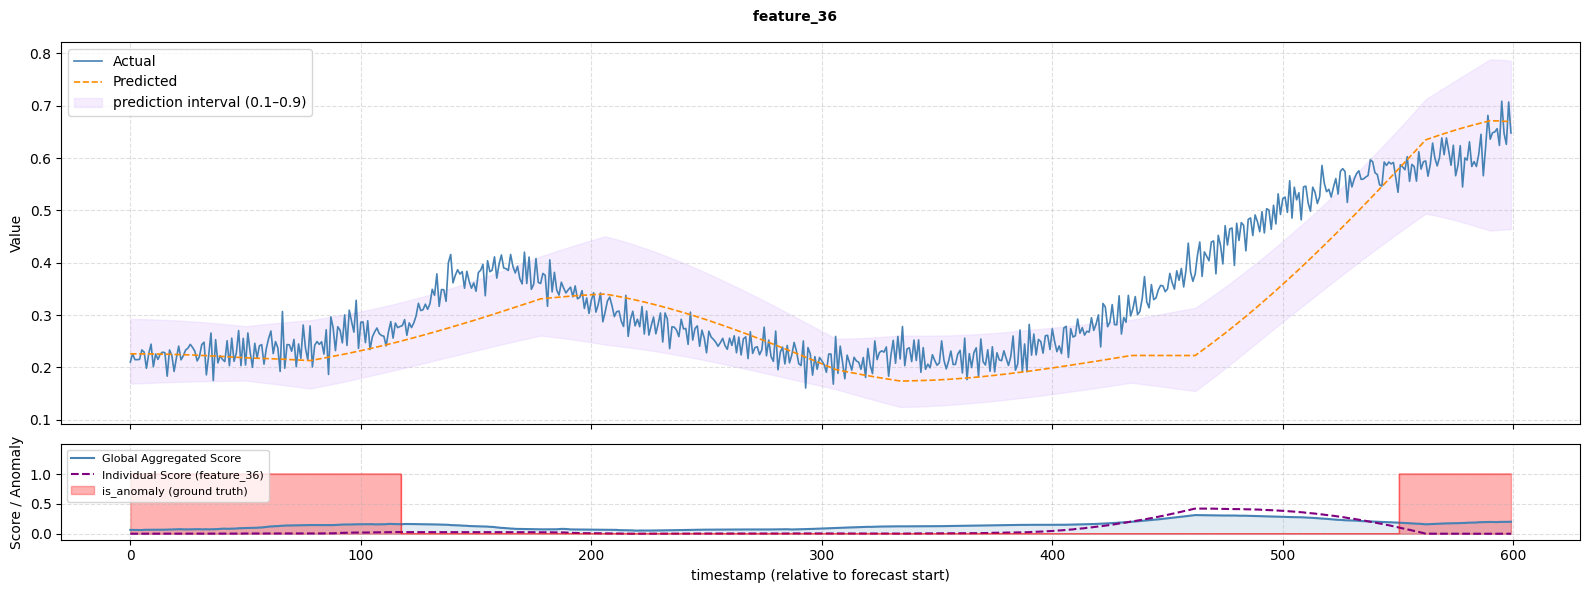

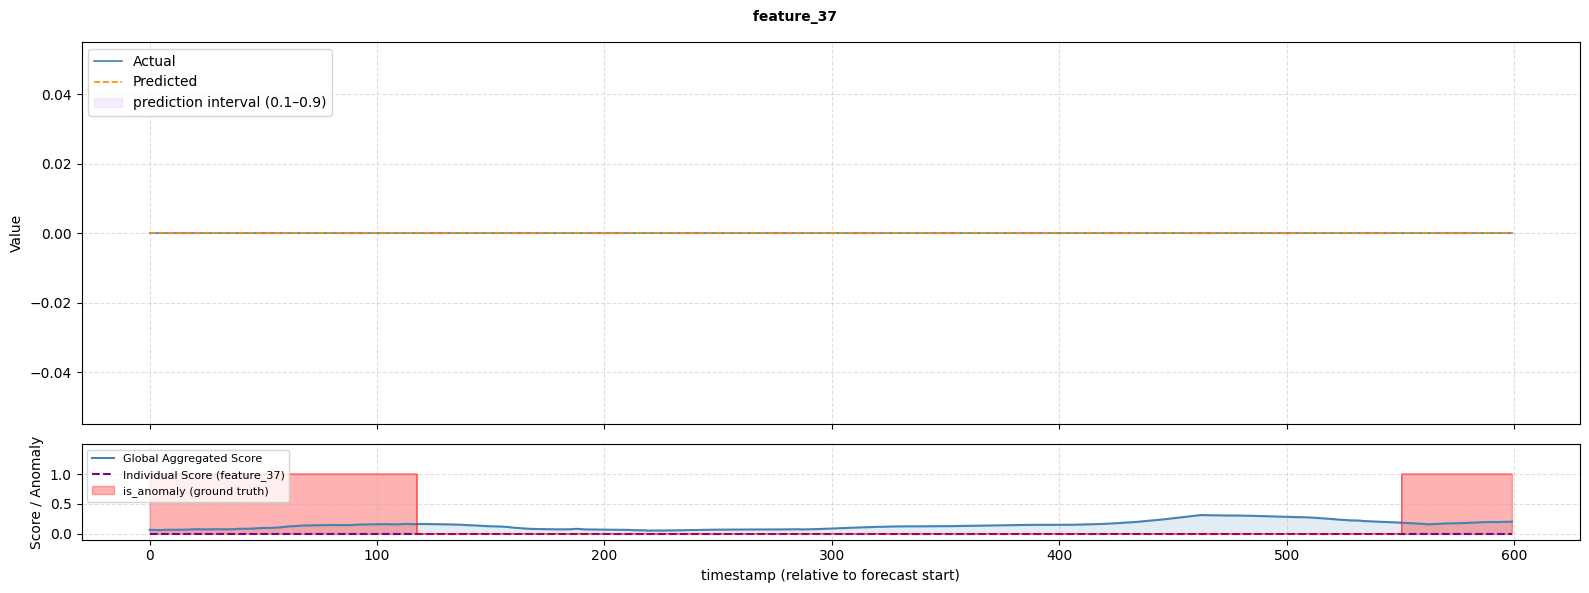

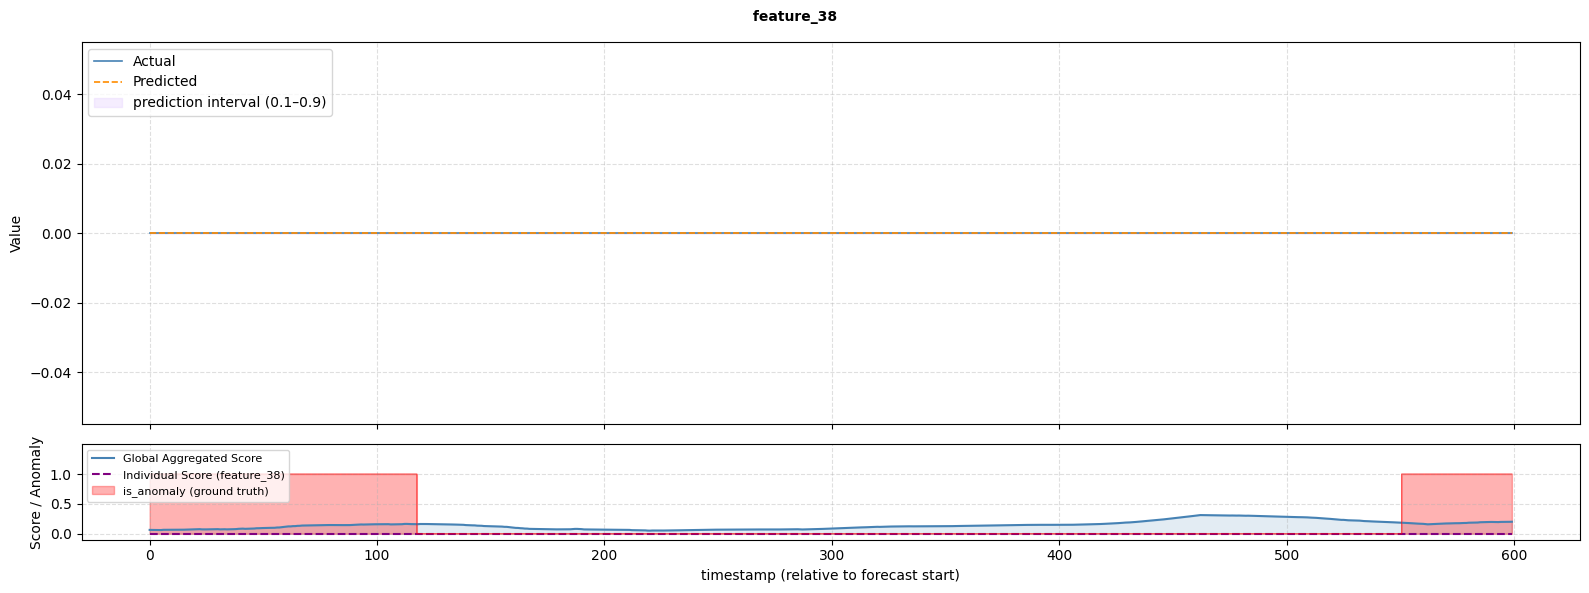

In [12]:
for i in range(len(feature_list)):
    plot_forecast_with_anomaly(
        feature_groups, df, y_score, anomaly_df, label, feature_list,
        feature_idx=i,
        plot_from=2944,
        plot_until=3544,
        smooth_window=100,
    )

### Full Forecast Region (no zoom)

Set `plot_from`/`plot_until` to `None` to see the entire forecast region. Useful for an initial overview.

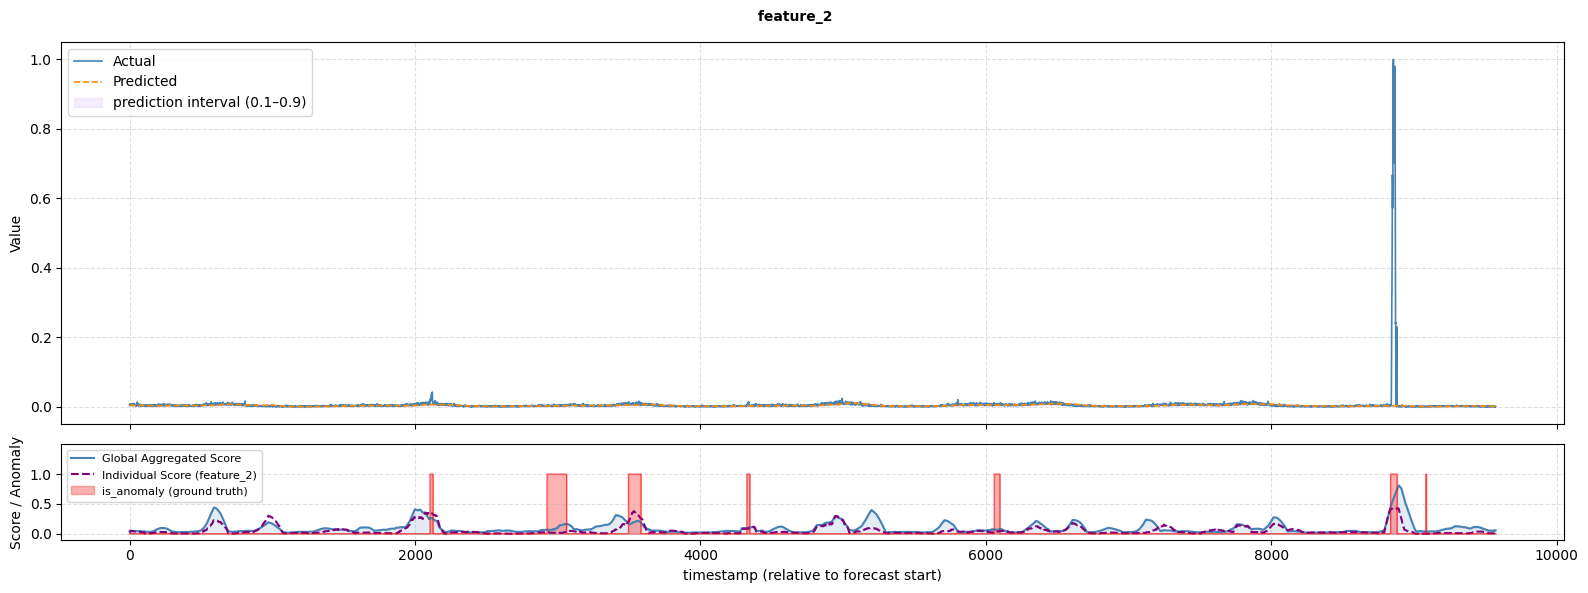

In [13]:
plot_forecast_with_anomaly(
    feature_groups, df, y_score, anomaly_df, label, feature_list,
    feature_idx=1,
    plot_from=None,
    plot_until=None,
    smooth_window=100,
)